### Estructura del notebook

| Módulo | Tema | Herramientas del curso |
|--------|------|----------------------|
| 0 | Constantes y unidades geométricas | Intervalo, cuadrivectores, signatura (−,+,+,+) |
| 1 | Dinámica newtoniana del disco | `odeint`, órbitas keplerianas, fricción |
| 2 | Relatividad especial | Factor de Lorentz, Herglotz, beaming, Doppler |
| 3 | Radiación térmica del disco | Shakura-Sunyaev, Planck, Wien, redshift gravitacional |
| 4 | Geodésicas en Schwarzschild | Potencial efectivo, ISCO, precesión orbital |
| 5 | Fotones y sombra del agujero negro | Geodésicas nulas, $b_{\mathrm{crit}}$, EHT M87* |
| 6 | Métrica de Kerr | Arrastre de marco, ISCO con espín |
| 7 | Síntesis: espectro observado | Integral de flujo completa |
| 8 | Jet astrofísico | Tensor de Faraday, EDM relativista, campo helicoidal |


## Módulo 0 — Constantes y Sistema de Unidades

### 0.1 Intervalo espacio-temporal y signatura

En el curso usamos la **signatura** $(-,+,+,+)$. El **intervalo invariante** es:

$$ds^2 = -c^2\,dt^2 + dx^2 + dy^2 + dz^2 \equiv \eta_{\mu\nu}\,dx^\mu\,dx^\nu$$

con $\eta_{\mu\nu} = \mathrm{diag}(-1,+1,+1,+1)$ la **métrica de Minkowski**.

### 0.2 Cuadrivelocidad y factor de Lorentz

El tiempo propio $\tau$ satisface $d\tau = dt\sqrt{1-v^2/c^2}$, por lo que:

$$\frac{dt}{d\tau} = \gamma \equiv \frac{1}{\sqrt{1-\beta^2}}, \quad \beta = v/c$$

La cuadrivelocidad $\tilde{U} = dx^\mu/d\tau$ tiene norma constante: $\eta_{\mu\nu}U^\mu U^\nu = -c^2$.

### 0.3 Sistemas de unidades empleados

- **Año-luz / año / $M_\odot$** para la dinámica newtoniana (Módulo 1): $c = 1\,\mathrm{al/año}$.
- **Unidades geométricas** ($G = c = 1$) para RG (Módulos 4–8): $R_s = 2M$, $R_{\mathrm{ISCO}} = 6M$.


In [17]:
# ═══════════════════════════════════════════════════════════════════
# MÓDULO 0: IMPORTS Y CONSTANTES
# ═══════════════════════════════════════════════════════════════════
import numpy as np                              # álgebra numérica
import sympy as sp                              # cálculo simbólico
import matplotlib.pyplot as plt                 # gráficas 2D
import matplotlib.gridspec as gridspec          # diseño de figuras
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Circle          # círculos en plots
from scipy.integrate import odeint, solve_ivp  # integradores numéricos ODE
import pandas as pd                             # tablas de resultados
from IPython.display import display             # salida simbólica en notebook

# ── Constantes físicas en SI ─────────────────────────────────────
c_SI     = 299_792_458        # velocidad de la luz              [m/s]
G_SI     = 6.674e-11          # constante gravitacional           [m³ kg⁻¹ s⁻²]
M_sol_SI = 1.989e30           # masa del Sol                      [kg]
k_B      = 1.380649e-23       # constante de Boltzmann            [J/K]
h_P      = 6.62607015e-34     # constante de Planck               [J·s]
b_Wien   = 2.897771955e-3     # constante de Wien                 [m·K]

# ── Sistema año-luz / año (c = 1) — usado en Módulo 1 ───────────
c   = 1.0                     # c en unidades relativistas (adimensional)
UT  = 365.25 * 86400          # 1 año en segundos
UL  = c_SI * UT               # 1 año-luz en metros
# G convertida a unidades (al, año, M_sol):
G   = G_SI * M_sol_SI * UT**2 / UL**3

M_BH   = 10.0                 # masa del agujero negro            [M_sol]
R_s    = 2 * G * M_BH / c**2  # radio de Schwarzschild            [al]
R_isco = 3 * R_s              # ISCO en Schwarzschild = 6M = 3Rs  [al]

# ── Unidades geométricas (G=c=1) — usadas en Módulos 4-8 ────────
# M_geo = 1.0, Rs_geo = 2.0, R_isco_geo = 6.0 (definidos localmente)

print(f"Sistema año-luz:")
print(f"  G         = {G:.4e} al³/(M_sol·año²)")
print(f"  R_s       = {R_s:.4e} al  =  {R_s*UL/1e3:.2f} km")
print(f"  R_ISCO    = {R_isco:.4e} al  =  {R_isco*UL/1e3:.2f} km")
print(f"  R_s/R_ISCO = 1/3 → {R_s/R_isco:.4f}")
print()
print("Unidades geométricas (G=c=1, M=1):")
print(f"  R_s = 2M = 2,  R_ISCO = 6M = 6")


Sistema año-luz:
  G         = 1.5612e-13 al³/(M_sol·año²)
  R_s       = 3.1224e-12 al  =  29.54 km
  R_ISCO    = 9.3671e-12 al  =  88.62 km
  R_s/R_ISCO = 1/3 → 0.3333

Unidades geométricas (G=c=1, M=1):
  R_s = 2M = 2,  R_ISCO = 6M = 6


## Módulo 1 — Dinámica Newtoniana del Disco de Acreción

### 1.1 Órbitas circulares y tercera ley de Kepler

El balance entre gravedad y aceleración centrípeta da la velocidad circular:

$$\boxed{v_c(r) = \sqrt{\frac{GM}{r}}}$$

El período orbital (tercera ley de Kepler):

$$T(r) = \frac{2\pi r}{v_c} = 2\pi\sqrt{\frac{r^3}{GM}}$$

### 1.2 Ecuaciones de movimiento con acreción débil

Para simular el flujo lento del gas hacia el agujero negro se añade una fricción viscosa débil $f_{\mathrm{drag}}$:

$$\dot{v}_x = -\frac{GM\,x}{r^3} + f_{\mathrm{drag}}\,v_x, \qquad \dot{v}_y = -\frac{GM\,y}{r^3} + f_{\mathrm{drag}}\,v_y$$

donde $f_{\mathrm{drag}} \approx -5\times10^{-5}\,\mathrm{año}^{-1}$ (pequeño y negativo → disipa energía orbital).

### 1.3 Integración numérica

Se usa `scipy.integrate.odeint` con el método Runge-Kutta implícito (Radau-II) con tolerancias mejoradas `rtol=1e-6, atol=1e-8` para conservar la energía orbital durante múltiples períodos.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MÓDULO 1: DINÁMICA NEWTONIANA — FUNCIONES
# ═══════════════════════════════════════════════════════════════════

def Vel_cir(r):
    """
    Velocidad circular kepleriana v_c = sqrt(GM/r).
    r: radio orbital [al]
    """
    return np.sqrt(G * M_BH / r)   # fórmula de balance centrípeto

def T_orb(r):
    """
    Período orbital T = 2π r / v_c = 2π sqrt(r³/GM).
    r: radio orbital [al]
    """
    return 2 * np.pi * r / Vel_cir(r)   # tercera ley de Kepler

def Equ_mov(state, t):
    """
    Sistema de EDOs para el movimiento gravitacional 2D con fricción débil.
    state = [x, y, vx, vy]  →  derivadas = [vx, vy, ax, ay]
    La fricción modela la viscosidad del disco (acreción).
    """
    x, y, vx, vy = state                   # desempaquetar posición y velocidad
    r  = np.sqrt(x**2 + y**2)             # distancia radial al BH
    drag = -5e-5                           # coeficiente de arrastre viscoso [1/año]
    ax = -G * M_BH * x / r**3 + drag * vx # aceleración x: gravedad newtoniana + fricción
    ay = -G * M_BH * y / r**3 + drag * vy # aceleración y: gravedad newtoniana + fricción
    return [vx, vy, ax, ay]               # retornar derivadas del estado

def Simulacion(n_particles=2000, t_max=None, n_steps=1500):
    """
    Simula N partículas de gas con condiciones iniciales casi circulares.
    Las partículas se distribuyen en radios r ∈ [1.05 R_ISCO, 20 R_s].
    Perturbación de excentricidad ≤ 0.08 para reproducir la turbulencia.
    """
    np.random.seed(42)   # fijar semilla para reproducibilidad

    r_min = R_isco * 1.05           # radio mínimo: ligeramente sobre ISCO
    r_max = 20 * R_s                # radio máximo: borde externo del disco
    radii  = np.random.uniform(r_min, r_max, n_particles)   # radios iniciales
    angles = np.random.uniform(0, 2*np.pi, n_particles)     # ángulos iniciales
    ecc    = np.random.uniform(0, 0.08, n_particles)        # excentricidades

    particles = []   # lista de diccionarios con trayectorias
    for i in range(n_particles):
        r   = radii[i]                       # radio de la partícula i
        phi = angles[i]                      # ángulo azimutal inicial
        # Velocidad casi circular con perturbación aleatoria de excentricidad
        v_c = Vel_cir(r) * (1 + ecc[i] * np.random.choice([-1, 1]))

        x  =  r * np.cos(phi)               # posición x inicial
        y  =  r * np.sin(phi)               # posición y inicial
        vx = -v_c * np.sin(phi)             # velocidad tangencial en x
        vy =  v_c * np.cos(phi)             # velocidad tangencial en y

        T     = T_orb(r)                     # período orbital de esta partícula
        t_max_i = 3 * T if t_max is None else t_max   # integrar 3 períodos
        t = np.linspace(0, t_max_i, n_steps) # array de tiempos

        # INTEGRACIÓN NUMÉRICA con odeint (Runge-Kutta adaptativo)
        # rtol=1e-6, atol=1e-8: tolerancias mejoradas respecto al notebook original
        sol = odeint(Equ_mov, [x, y, vx, vy], t, rtol=1e-6, atol=1e-8)

        # Eliminar puntos donde la partícula cayó al horizonte
        r_traj = np.sqrt(sol[:, 0]**2 + sol[:, 1]**2)   # radio en cada paso
        mask   = r_traj > R_s * 1.1                       # filtrar r > 1.1 Rs
        if mask.sum() > 10:                               # solo si quedan puntos
            particles.append({
                'x'     : sol[mask, 0],   # posiciones x filtradas
                'y'     : sol[mask, 1],   # posiciones y filtradas
                'vx'    : sol[mask, 2],   # velocidades vx filtradas
                'vy'    : sol[mask, 3],   # velocidades vy filtradas
                'r0'    : r,              # radio inicial (para colormap)
                'r_traj': r_traj[mask],   # radios filtrados
            })
    return particles   # lista de N trayectorias

# ── Verificación simbólica ────────────────────────────────────────
G_s, M_s, r_s = sp.symbols('G M r', positive=True)
v_c_sym = sp.sqrt(G_s * M_s / r_s)
T_sym   = sp.simplify(2 * sp.pi * r_s / v_c_sym)
print("Velocidad circular:")
display(sp.Eq(sp.Symbol('v_c'), v_c_sym))
print("Período orbital (3ª ley de Kepler):")
display(sp.Eq(sp.Symbol('T'), T_sym))


Velocidad circular:


Eq(v_c, sqrt(G)*sqrt(M)/sqrt(r))

Período orbital (3ª ley de Kepler):


Eq(T, 2*pi*r**(3/2)/(sqrt(G)*sqrt(M)))

Simulando disco newtoniano (2000 partículas)...


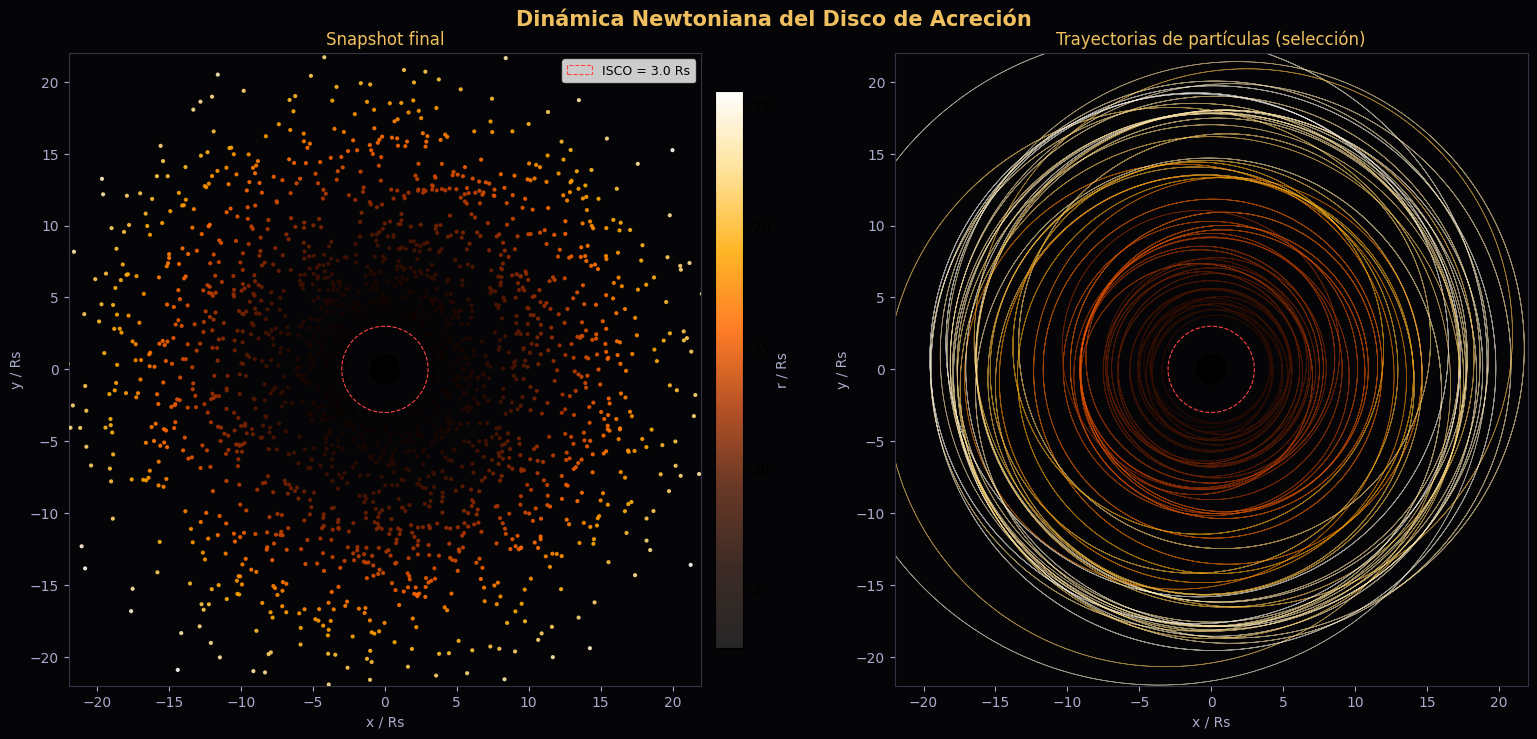

Partículas simuladas: 2000
Velocidad circular en ISCO: v_c = 122389.8 km/s


In [19]:
# ─── Colormap del disco de acreción ──────────────────────────────
def make_black_hole_colormap():
    """
    Colormap personalizado: negro → naranja → amarillo → blanco.
    Simula la temperatura del gas: más interno = más caliente = más brillante.
    """
    colors = ['#000000', '#1a0500', '#4d1500', '#a83200',
              '#ff6600', '#ffaa00', '#ffdd88', '#ffffff']
    return LinearSegmentedColormap.from_list('accretion', colors, N=512)

def plot_simulation(particles, title="Dinámica Newtoniana del Disco de Acreción"):
    """
    Visualiza la simulación newtoniana:
    - Panel izquierdo: snapshot final (posición actual de cada partícula)
    - Panel derecho:   trayectorias (últimas 3 órbitas de 60 partículas)
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), facecolor='#050508')
    fig.suptitle(title, color='#f0c060', fontsize=15, fontweight='bold', y=0.97)
    for ax in axes:
        ax.set_facecolor('#050508')
        for sp_ax in ax.spines.values(): sp_ax.set_color('#333344')
        ax.tick_params(colors='#aaaacc')
        ax.xaxis.label.set_color('#aaaacc'); ax.yaxis.label.set_color('#aaaacc')
    scale    = R_s                          # normalizar posiciones en unidades de Rs
    cmap_disk = make_black_hole_colormap()  # colormap del disco

    # Panel izquierdo: snapshot final coloreado por radio
    ax0 = axes[0]; ax0.set_title("Snapshot final", color='#f0c060', fontsize=12)
    snap_x = [p['x'][-1]/scale for p in particles]  # posición x final
    snap_y = [p['y'][-1]/scale for p in particles]  # posición y final
    snap_r = [p['r_traj'][-1]/scale for p in particles]  # radio final
    snap_x, snap_y, snap_r = map(np.array, [snap_x, snap_y, snap_r])
    norm_r = Normalize(vmin=snap_r.min(), vmax=snap_r.max())
    sc  = ax0.scatter(snap_x, snap_y, c=snap_r, cmap=cmap_disk, s=4, alpha=0.85,
                      norm=norm_r, zorder=3)
    ax0.add_patch(Circle((0,0), R_s/scale, color='black', zorder=10))    # agujero negro
    ax0.add_patch(Circle((0,0), R_isco/scale, fill=False, edgecolor='#ff4444',
                          linewidth=0.8, linestyle='--', zorder=5,
                          label=f"ISCO = {R_isco/scale:.1f} Rs"))        # ISCO
    ax0.set_xlim(-22, 22); ax0.set_ylim(-22, 22); ax0.set_aspect('equal')
    ax0.set_xlabel("x / Rs"); ax0.set_ylabel("y / Rs"); ax0.legend(fontsize=9)
    cbar = fig.colorbar(sc, ax=ax0, fraction=0.04, pad=0.02)
    cbar.set_label("r / Rs", color='#aaaacc')

    # Panel derecho: trayectorias (submuestra de 60 partículas)
    ax1 = axes[1]; ax1.set_title("Trayectorias de partículas (selección)", color='#f0c060')
    shown = particles[::max(1, len(particles)//60)]   # seleccionar 1 de cada N
    for p in shown:
        r_norm = p['r0'] / (20 * R_s)               # normalizar para colormap
        ax1.plot(p['x']/scale, p['y']/scale, color=cmap_disk(r_norm),
                 linewidth=0.5, alpha=0.6)
    ax1.add_patch(Circle((0,0), R_s/scale, color='black', zorder=10))
    ax1.add_patch(Circle((0,0), R_isco/scale, fill=False, edgecolor='#ff4444',
                          linewidth=0.8, linestyle='--', zorder=5))
    ax1.set_xlim(-22, 22); ax1.set_ylim(-22, 22); ax1.set_aspect('equal')
    ax1.set_xlabel("x / Rs"); ax1.set_ylabel("y / Rs")
    plt.tight_layout(); plt.show()

# ─── EJECUTAR MÓDULO 1 ─────────────────────────────────────────────
print("Simulando disco newtoniano (2000 partículas)...")
particles = Simulacion(n_particles=2000, n_steps=1500)
plot_simulation(particles)
print(f"Partículas simuladas: {len(particles)}")
print(f"Velocidad circular en ISCO: v_c = {Vel_cir(R_isco)*c_SI/1e3:.1f} km/s")


## Módulo 2 — Relatividad Especial: Factor de Lorentz, Doppler y *Beaming*

### 2.1 Transformaciones de Herglotz (boost general)

Para un observador $S'$ que se mueve con velocidad $\vec{u}$ respecto a $S$:

$$\gamma \equiv \frac{1}{\sqrt{1-u^2/c^2}}, \qquad t' = \gamma\left(t - \frac{\vec{u}\cdot\vec{r}}{c^2}\right)$$

El **cuadrivector de onda** del fotón $\tilde{k}: (\omega/c, \vec{k})$ transforma como cualquier cuadrivector.

### 2.2 Factor Doppler relativista

Aplicando la transformación de Herglotz al cuadrivector de onda con la fuente moviéndose a velocidad $\beta c$ y el ángulo $\theta$ entre la velocidad y la línea de visión:

$$\boxed{\delta \equiv \gamma(1-\beta\cos\theta)}$$

- $\delta < 1$ (fuente se acerca): corrimiento al **azul** ($\lambda_{\mathrm{obs}} < \lambda_{\mathrm{emit}}$).  
- $\delta > 1$ (fuente se aleja): corrimiento al **rojo** ($\lambda_{\mathrm{obs}} > \lambda_{\mathrm{emit}}$).

### 2.3 *Beaming* relativista

La intensidad específica transforma como $I_\nu/\nu^3 = \text{const}$, por lo que el flujo integrado:

$$\boxed{F_{\mathrm{obs}} = \frac{F_{\mathrm{emit}}}{\delta^3}}$$

A velocidades relativistas, $\delta \ll 1$ en la dirección de movimiento → amplificación enorme.

### 2.4 Corrimiento gravitacional en Schwarzschild

Un fotón emitido a radio $r$ y recibido en el infinito sufre:

$$\frac{\lambda_{\mathrm{obs}}}{\lambda_{\mathrm{emit}}} = \frac{1}{\sqrt{1-R_s/r}}$$

La longitud de onda combinada (Doppler + gravitacional):

$$\boxed{\lambda_{\mathrm{obs}} = \lambda_{\mathrm{emit}}\cdot\delta\cdot\frac{1}{\sqrt{1-R_s/r}}}$$


Prueba beaming — β=0.3, θ=0°:
  γ = 1.0483
  δ = γ(1-β) = 0.7338  (<1 → corrimiento al azul)
  Amplificación de flujo: F_obs/F_emit = 1/δ³ = 2.53


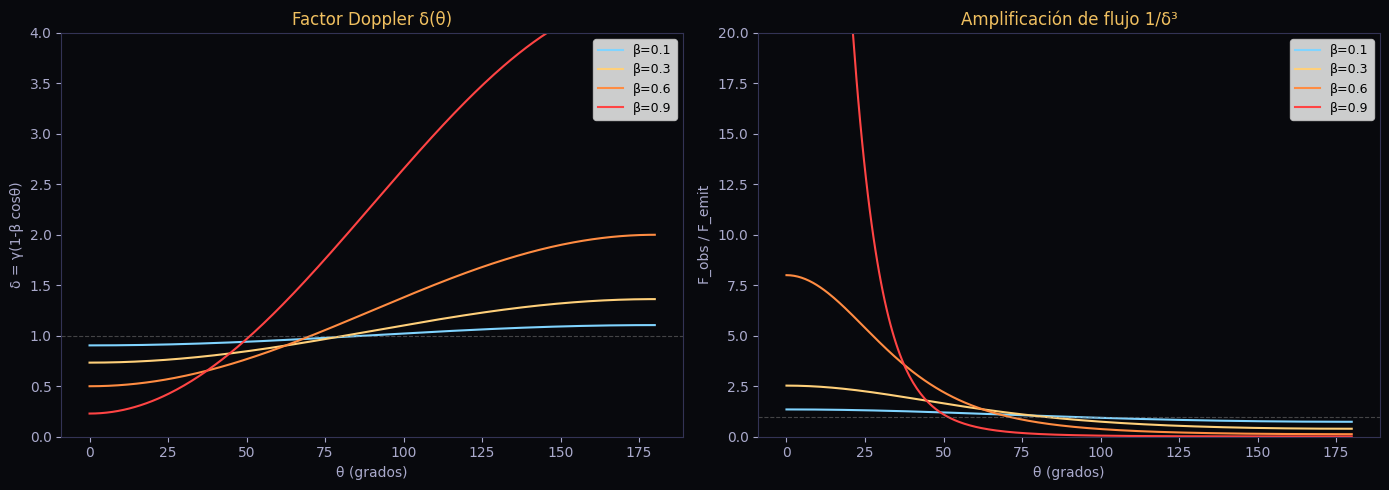

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MÓDULO 2: FUNCIONES DE RELATIVIDAD ESPECIAL
# ═══════════════════════════════════════════════════════════════════

def Factor_L(v):
    """
    Factor de Lorentz: γ = 1/√(1 - β²), β = v/c.
    Se usa c=1 (unidades geométricas). El clip evita singularidades numéricas.
    """
    beta = np.clip(np.abs(v) / c, 0, 0.9999)   # β = |v|/c limitado a [0, 0.9999]
    return 1.0 / np.sqrt(1 - beta**2)          # factor de Lorentz γ

def Beaming_r(flux_rest, gamma, cos_theta):
    """
    Beaming relativista: F_obs = F_rest / δ³
    donde δ = γ(1 - β cos θ) es el factor Doppler.
    - flux_rest: flujo en el marco de la fuente (proporcional a T⁴)
    - gamma    : factor de Lorentz γ de la fuente
    - cos_theta: coseno del ángulo entre velocidad y línea de visión
    """
    beta   = np.sqrt(1 - 1/gamma**2)          # β = √(1 - 1/γ²)
    doppler = gamma * (1 - beta * cos_theta)  # factor Doppler δ = γ(1 - β cos θ)
    doppler = np.clip(doppler, 1e-6, 1e6)     # evitar división por cero
    return flux_rest / doppler**3              # F_obs = F_emit / δ³

def Doppler(lambda_rest, gamma, cos_theta):
    """
    Desplazamiento Doppler relativista: λ_obs = λ_rest × δ
    Derivado del boost de Lorentz sobre el cuadrivector de onda k^μ.
    """
    beta = np.sqrt(1 - 1/gamma**2)                         # β desde γ
    return lambda_rest * gamma * (1 - beta * cos_theta)   # λ_obs = λ × δ

def Redshift(lambda_emit, r):
    """
    Corrimiento gravitacional al rojo en métrica de Schwarzschild.
    λ_obs = λ_emit / √(1 - R_s/r)
    Clip en r para evitar evaluar cerca o dentro del horizonte.
    """
    factor = np.sqrt(1 - R_s / np.clip(r, R_s*1.01, 1e20))  # √(1 - Rs/r)
    return lambda_emit / factor                               # λ_obs = λ / √(...)

# ── Verificación analítica: δ para β=0.3, θ=0 ────────────────────
beta_test   = 0.3
gamma_test  = 1 / np.sqrt(1 - beta_test**2)
delta_test  = gamma_test * (1 - beta_test * 1.0)   # cos θ = 1 (se acerca)
print(f"Prueba beaming — β={beta_test}, θ=0°:")
print(f"  γ = {gamma_test:.4f}")
print(f"  δ = γ(1-β) = {delta_test:.4f}  (<1 → corrimiento al azul)")
print(f"  Amplificación de flujo: F_obs/F_emit = 1/δ³ = {1/delta_test**3:.2f}")

# ── Gráfica del beaming en función del ángulo ─────────────────────
beta_vals = [0.1, 0.3, 0.6, 0.9]
theta_arr = np.linspace(0, np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#08090d')
for ax in axes:
    ax.set_facecolor('#08090d'); ax.tick_params(colors='#aaaacc')
    for sp_ax in ax.spines.values(): sp_ax.set_color('#333355')

ax = axes[0]; ax.set_title('Factor Doppler δ(θ)', color='#f0c060')
for beta, col in zip(beta_vals, ['#80d4ff','#ffd07a','#ff8c42','#ff4444']):
    gamma = 1/np.sqrt(1-beta**2)
    delta = gamma * (1 - beta * np.cos(theta_arr))
    ax.plot(np.degrees(theta_arr), delta, color=col, label=f'β={beta}')
ax.axhline(1, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('θ (grados)', color='#aaaacc'); ax.set_ylabel('δ = γ(1-β cosθ)', color='#aaaacc')
ax.legend(fontsize=9); ax.set_ylim(0, 4)

ax = axes[1]; ax.set_title('Amplificación de flujo 1/δ³', color='#f0c060')
for beta, col in zip(beta_vals, ['#80d4ff','#ffd07a','#ff8c42','#ff4444']):
    gamma = 1/np.sqrt(1-beta**2)
    delta = gamma * (1 - beta * np.cos(theta_arr))
    ax.plot(np.degrees(theta_arr), 1/np.clip(delta,1e-6,1e10)**3,
            color=col, label=f'β={beta}')
ax.axhline(1, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('θ (grados)', color='#aaaacc'); ax.set_ylabel('F_obs / F_emit', color='#aaaacc')
ax.legend(fontsize=9); ax.set_ylim(0, 20)
plt.tight_layout(); plt.show()


## Módulo 3 — Radiación Térmica del Disco

### 3.1 Perfil de temperatura de Shakura-Sunyaev (1973)

En un disco en estado estacionario, la disipación viscosa produce el perfil:

$$\boxed{T(r) = T_0\left(\frac{R_{\mathrm{ISCO}}}{r}\right)^{3/4}\left(1-\sqrt{\frac{R_{\mathrm{ISCO}}}{r}}\right)^{1/4}}$$

- El factor $(R_i/r)^{3/4}$ refleja la mayor disipación en las regiones internas.  
- El término de borde $(1-\sqrt{R_i/r})^{1/4}$ garantiza $T(R_{\mathrm{ISCO}})=0$.  
- Para $T_0 = 10^7\,\mathrm{K}$: $\lambda_{\mathrm{pico}} \approx 0.29\,\mathrm{nm}$ (rayos X blandos).

### 3.2 Función de Planck y ley de Wien

$$B_\lambda(T) = \frac{2hc^2}{\lambda^5}\frac{1}{e^{hc/(\lambda k_B T)}-1}$$

El pico de emisión: $\lambda_{\mathrm{pico}} = b/T$ con $b = 2.898\times10^{-3}\,\mathrm{m\cdot K}$.

### 3.3 Mapa 2D del disco

Para cada celda $(r, \phi)$ del disco kepleriano con inclinación $i$:

$$\cos\theta(r,\phi) = \sin(i)\,\sin(\phi), \qquad \delta = \gamma(r)(1-\beta(r)\sin(i)\sin(\phi))$$

$$I_{\mathrm{obs}}(r,\phi,i) = \frac{\sigma T(r)^4}{\delta^3}\sqrt{1-\frac{R_s}{r}}, \qquad \lambda_{\mathrm{obs}} = \frac{b}{T(r)}\cdot\delta\cdot\frac{1}{\sqrt{1-R_s/r}}$$


Perfil Shakura-Sunyaev:


Eq(T(r), R_i**(3/4)*T_0*(-sqrt(R_i)/sqrt(r) + 1)**(1/4)/r**(3/4))


Ley de Wien: λ_pico = b/T = 0.290 nm → Rayos X blandos


/var/folders/lq/q6gckjc95cs95tcthk478wf80000gn/T/ipykernel_17346/3574584738.py:25: RuntimeWarning: overflow encountered in exp
  return (2 * h_P * c_SI**2 / lam_m**5) / (np.exp(exp_arg) - 1)


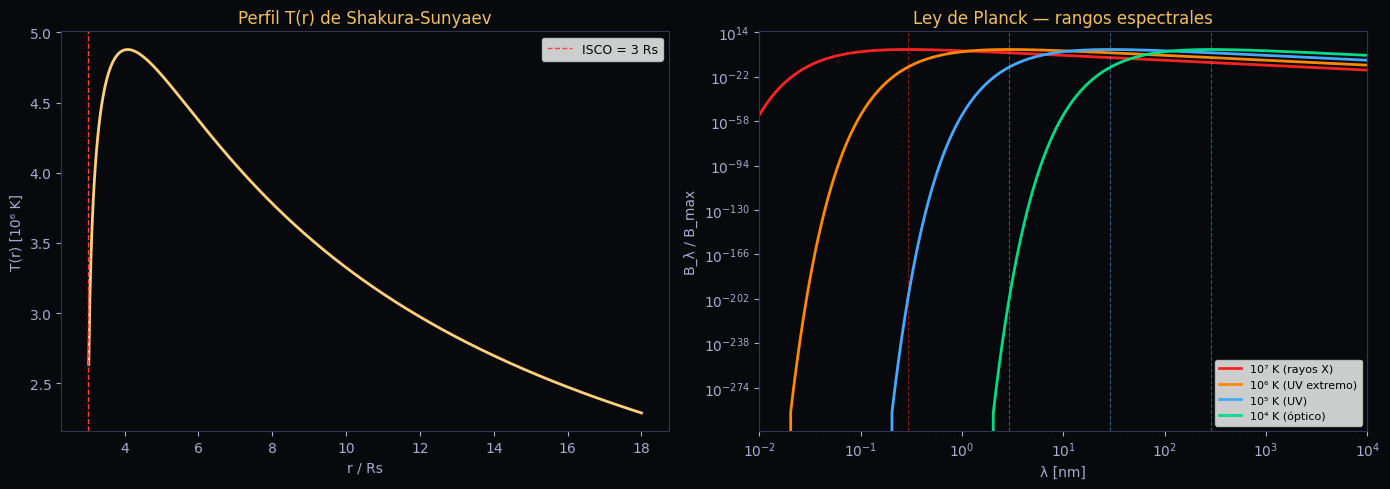

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MÓDULO 3: RADIACIÓN TÉRMICA Y MAPAS DE EMISIÓN
# ═══════════════════════════════════════════════════════════════════

def T_disco(r):
    """
    Perfil de temperatura de Shakura-Sunyaev.
    T(r) = T_max × (R_isco/r)^(3/4) × (1 - sqrt(R_isco/r))^(1/4)
    Retorna 0 para r ≤ R_isco (condición de borde en la ISCO).
    """
    if r <= R_isco:
        return 0                             # no hay disco dentro de la ISCO
    T_max = 1e7                              # temperatura máxima [K] (rayos X)
    x     = R_isco / r                       # razón R_isco/r
    return T_max * (r/R_isco)**(-3/4) * max((1 - np.sqrt(x)), 0)**0.25

def planck_nm(lam_nm, T):
    """
    Función de Planck B_λ(T) evaluada en λ [nm] y T [K].
    Retorna la intensidad espectral [W m⁻³ sr⁻¹].
    """
    lam_m   = lam_nm * 1e-9                              # convertir nm → m
    exp_arg = h_P * c_SI / (lam_m * k_B * T)            # argumento del exponente
    return (2 * h_P * c_SI**2 / lam_m**5) / (np.exp(exp_arg) - 1)

def Mapa_Disco(N_r=80, N_phi=200, obs_angle_deg=75):
    """
    Calcula el mapa 2D del disco kepleriano para una inclinación dada.
    Retorna mallas 2D de: R, PHI, F_obs, lambda_obs, T, V_kep, Gamma.

    Pasos:
      1) Crear malla (r, phi) sobre el disco
      2) Calcular v_kep(r) y factor Lorentz γ
      3) Proyectar velocidad sobre línea de visión: cos θ = sin(i) sin(φ)
      4) Aplicar beaming: F_obs = T⁴ / δ³
      5) Calcular λ_obs = λ_Wien × δ × f_grav
    """
    obs_inc = np.radians(obs_angle_deg)    # inclinación en radianes

    r_arr   = np.linspace(R_isco*1.05, 18*R_s, N_r)          # radios [al]
    phi_arr = np.linspace(0, 2*np.pi, N_phi, endpoint=False)  # ángulos [rad]
    PHI, R  = np.meshgrid(phi_arr, r_arr)                     # malla 2D

    # Velocidad kepleriana en cada celda (c=1 en unidades geométricas)
    V_kep = np.sqrt(G * M_BH / R)                   # v_c = sqrt(GM/r)

    # Componente de velocidad a lo largo de la línea de visión
    # v_los = v_kep × sin(phi) × sin(i)  →  cos θ = sin(phi)×sin(i)
    V_los     = V_kep * np.sin(PHI) * np.sin(obs_inc)
    GAMMA     = Factor_L(V_kep)                      # γ = 1/√(1-β²)
    COS_THETA = np.where(V_kep > 0, V_los/V_kep, 0) # cos θ = sin(φ)sin(i)

    # Temperatura y flujo en reposo (Stefan-Boltzmann: F ∝ T⁴)
    T_mat  = np.vectorize(T_disco)(R)                # temperatura en cada celda
    F_rest = np.where(T_mat > 0, T_mat**4, 0)        # flujo en marco propio

    # Flujo observado con beaming relativista
    F_obs = Beaming_r(F_rest, GAMMA, COS_THETA)      # F_obs = F_rest / δ³

    # Longitud de onda de Wien en reposo
    lam_rest = np.where(T_mat > 0, b_Wien/T_mat*1e9, 0)  # λ = b/T [nm]

    # Factor Doppler y redshift gravitacional combinados:
    # λ_obs = λ_rest × δ_Doppler × (1/√(1-Rs/r))
    delta_doppler = GAMMA * (1 - V_kep * COS_THETA)          # δ = γ(1-β cosθ)
    grav_redshift = 1.0 / np.sqrt(np.clip(1 - R_s/R, 1e-6, 1)) # 1/√(1-Rs/r)
    lam_obs = lam_rest * delta_doppler * grav_redshift        # λ_obs combinada

    return R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA

# ── Verificación simbólica del perfil Shakura-Sunyaev ─────────────
T0_s, R_i_s, r_v = sp.symbols('T_0 R_i r', positive=True)
T_r_sym = T0_s*(R_i_s/r_v)**sp.Rational(3,4) * (1-sp.sqrt(R_i_s/r_v))**sp.Rational(1,4)
print("Perfil Shakura-Sunyaev:")
display(sp.Eq(sp.Symbol('T(r)'), T_r_sym))
T0 = 1e7
print(f"\nLey de Wien: λ_pico = b/T = {b_Wien/T0*1e9:.3f} nm → Rayos X blandos")

# ── Gráfica del perfil de temperatura ────────────────────────────
r_plot = np.linspace(R_isco*1.01, 18*R_s, 500)
T_plot = np.array([T_disco(r) for r in r_plot])
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#08090d')
for ax in axes:
    ax.set_facecolor('#08090d'); ax.tick_params(colors='#aaaacc')
    for sp_ax in ax.spines.values(): sp_ax.set_color('#333355')
ax = axes[0]; ax.set_title('Perfil T(r) de Shakura-Sunyaev', color='#f0c060')
ax.plot(r_plot/R_s, T_plot/1e6, color='#ffd07a', lw=2)
ax.axvline(R_isco/R_s, color='#ff4444', lw=1, ls='--', label='ISCO = 3 Rs')
ax.set_xlabel('r / Rs', color='#aaaacc'); ax.set_ylabel('T(r) [10⁶ K]', color='#aaaacc')
ax.legend(fontsize=9)

lam_range = np.logspace(-2, 4, 2000)
ax = axes[1]; ax.set_title('Ley de Planck — rangos espectrales', color='#f0c060')
for T_val, col, lbl in [(1e7,'#ff2222','10⁷ K (rayos X)'), (1e6,'#ff8800','10⁶ K (UV extremo)'),
                         (1e5,'#44aaff','10⁵ K (UV)'), (1e4,'#00dd88','10⁴ K (óptico)')]:
    B = planck_nm(lam_range, T_val)
    ax.loglog(lam_range, B/B.max(), color=col, lw=2, label=lbl)
    ax.axvline(b_Wien/T_val*1e9, color=col, lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('λ [nm]', color='#aaaacc'); ax.set_ylabel('B_λ / B_max', color='#aaaacc')
ax.set_xlim(0.01, 1e4); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


Generando mapas de flujo con beaming relativista...


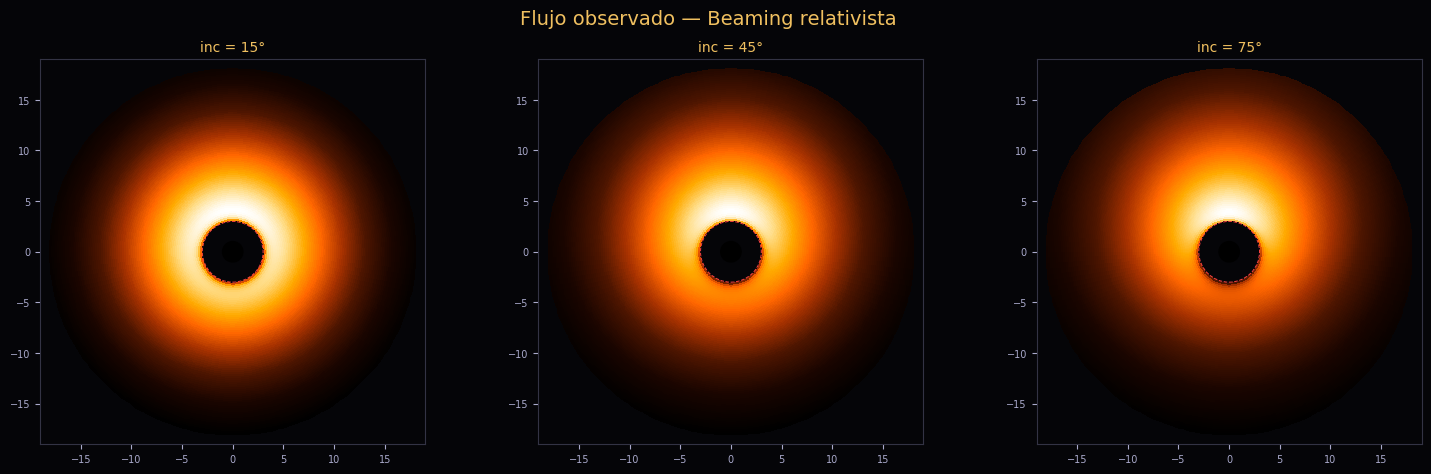

Generando mapas de desplazamiento espectral...


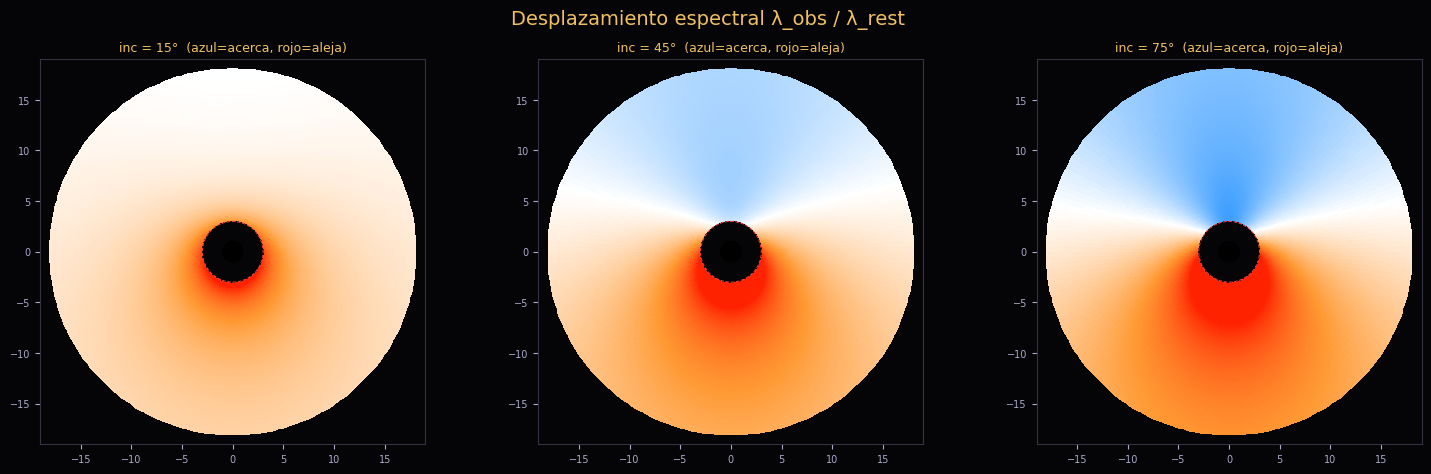

Generando perfiles radiales de flujo...


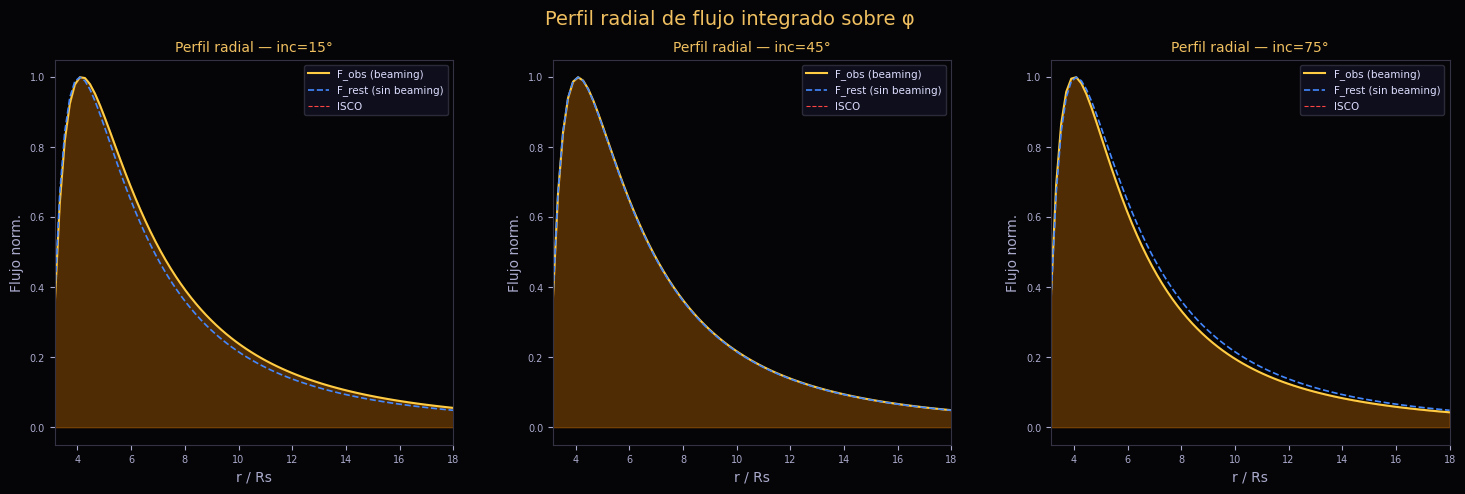

In [22]:
# ─── Funciones de visualización de los mapas del disco ───────────

def _estilo_ax(ax):
    """Aplicar estilo oscuro a un eje."""    
    ax.set_facecolor('#050508')
    for sp_ax in ax.spines.values(): sp_ax.set_color('#333344')
    ax.tick_params(colors='#aaaacc', labelsize=7)

def plot_flux_maps(obs_angles=(15, 45, 75)):
    """Mapa 2D del flujo observado (con beaming) para cada ángulo de inclinación."""    
    n = len(obs_angles)
    fig = plt.figure(figsize=(6*n, 5), facecolor='#050508')
    gs  = gridspec.GridSpec(1, n, hspace=0.35, wspace=0.25)
    fig.suptitle("Flujo observado — Beaming relativista", color='#f0c060', fontsize=14, y=0.98)
    cmap_flux = make_black_hole_colormap()
    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, _ = Mapa_Disco(obs_angle_deg=inc)
        ax = fig.add_subplot(gs[0, col]); _estilo_ax(ax)
        F_log = np.log10(np.clip(F_obs, 1, None))   # escala logarítmica
        dr = R[1,0]-R[0,0]
        r_e   = np.linspace(R[0,0]-dr/2, R[-1,0]+dr/2, R.shape[0]+1)
        phi_e = np.linspace(0, 2*np.pi, PHI.shape[1]+1)
        PE, RE = np.meshgrid(phi_e, r_e)
        ax.pcolormesh(RE*np.cos(PE)/R_s, RE*np.sin(PE)/R_s, F_log, cmap=cmap_flux, shading='auto')
        ax.add_patch(Circle((0,0), 1.0, color='black', zorder=5))          # horizonte
        ax.add_patch(Circle((0,0), 3.0, fill=False, edgecolor='#ff4444',
                             linewidth=0.7, linestyle='--', zorder=6))     # ISCO
        ax.set_aspect('equal'); ax.set_xlim(-19,19); ax.set_ylim(-19,19)
        ax.set_title(f"inc = {inc}°", color='#f0c060', fontsize=10)
    plt.show()

def plot_spectral_ratio_maps(obs_angles=(15, 45, 75)):
    """Mapa 2D de la razón λ_obs/λ_rest (desplazamiento espectral combinado)."""    
    n = len(obs_angles)
    fig = plt.figure(figsize=(6*n, 5), facecolor='#050508')
    gs  = gridspec.GridSpec(1, n, hspace=0.35, wspace=0.25)
    fig.suptitle("Desplazamiento espectral λ_obs / λ_rest", color='#f0c060', fontsize=14, y=0.98)
    cmap_shift = LinearSegmentedColormap.from_list(
        'doppler', ['#0033ff','#3399ff','#ffffff','#ff9933','#ff2200'], N=512)
    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, _, _ = Mapa_Disco(obs_angle_deg=inc)
        ax = fig.add_subplot(gs[0, col]); _estilo_ax(ax)
        lam_rest_map = np.where(T_mat > 0, b_Wien/T_mat*1e9, np.nan)
        ratio = np.where(lam_rest_map > 0, lam_obs/lam_rest_map, np.nan)
        dr = R[1,0]-R[0,0]
        r_e   = np.linspace(R[0,0]-dr/2, R[-1,0]+dr/2, R.shape[0]+1)
        phi_e = np.linspace(0, 2*np.pi, PHI.shape[1]+1)
        PE, RE = np.meshgrid(phi_e, r_e)
        ax.pcolormesh(RE*np.cos(PE)/R_s, RE*np.sin(PE)/R_s, ratio,
                      cmap=cmap_shift, shading='auto', vmin=0.6, vmax=1.4)
        ax.add_patch(Circle((0,0), 1.0, color='black', zorder=5))
        ax.add_patch(Circle((0,0), 3.0, fill=False, edgecolor='#ff4444',
                             linewidth=0.7, linestyle='--', zorder=6))
        ax.set_aspect('equal'); ax.set_xlim(-19,19); ax.set_ylim(-19,19)
        ax.set_title(f"inc = {inc}°  (azul=acerca, rojo=aleja)", color='#f0c060', fontsize=9)
    plt.show()

def plot_radial_flux_profiles(obs_angles=(15, 45, 75)):
    """Perfil radial de flujo integrado sobre φ: F_obs vs F_rest."""    
    n = len(obs_angles)
    fig = plt.figure(figsize=(6*n, 5), facecolor='#050508')
    gs  = gridspec.GridSpec(1, n, hspace=0.35, wspace=0.25)
    fig.suptitle("Perfil radial de flujo integrado sobre φ", color='#f0c060', fontsize=14, y=0.98)
    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, _, T_mat, _, _ = Mapa_Disco(obs_angle_deg=inc)
        ax = fig.add_subplot(gs[0, col]); _estilo_ax(ax)
        r_vals = R[:,0]/R_s
        fn = np.nansum(F_obs, axis=1); fn = fn / max(fn.max(), 1)   # normalizar
        fr = np.nansum(T_mat**4, axis=1); fr = fr / max(fr.max(), 1)
        ax.fill_between(r_vals, fn, alpha=0.3, color='#ff8800')
        ax.plot(r_vals, fn, '#ffcc44', lw=1.5, label='F_obs (beaming)')
        ax.plot(r_vals, fr, '#4488ff', lw=1.2, ls='--', label='F_rest (sin beaming)')
        ax.axvline(3, color='#ff4444', lw=0.8, ls='--', label='ISCO')
        ax.set_xlabel("r / Rs", color='#aaaacc'); ax.set_ylabel("Flujo norm.", color='#aaaacc')
        ax.set_title(f"Perfil radial — inc={inc}°", color='#f0c060', fontsize=10)
        ax.legend(fontsize=7.5, facecolor='#111122', edgecolor='#334', labelcolor='#ddddff')
        ax.set_xlim(r_vals.min(), r_vals.max())
    plt.show()

# ─── EJECUTAR MÓDULOS 2-3 ─────────────────────────────────────────
print("Generando mapas de flujo con beaming relativista...")
plot_flux_maps(obs_angles=(15, 45, 75))
print("Generando mapas de desplazamiento espectral...")
plot_spectral_ratio_maps(obs_angles=(15, 45, 75))
print("Generando perfiles radiales de flujo...")
plot_radial_flux_profiles(obs_angles=(15, 45, 75))


## Módulo 4 — Geodésicas en la Métrica de Schwarzschild

### 4.1 Métrica de Schwarzschild y constantes de movimiento

La solución de Einstein para el exterior de una masa esférica:

$$ds^2 = -\left(1-\frac{R_s}{r}\right)dt^2 + \frac{dr^2}{1-R_s/r} + r^2 d\Omega^2 \qquad (G=c=1)$$

Las simetrías bajo traslaciones en $t$ y $\phi$ garantizan dos constantes de movimiento:

$$E = \left(1-\frac{2M}{r}\right)\frac{dt}{d\tau}, \qquad L = r^2\frac{d\phi}{d\tau}$$

### 4.2 Potencial efectivo y ecuación radial

De la condición de normalización $g_{\mu\nu}u^\mu u^\nu = -1$:

$$V_{\mathrm{eff}}(r) = \left(1-\frac{2M}{r}\right)\left(1+\frac{L^2}{r^2}\right)$$

$$\frac{d^2r}{d\tau^2} = -\frac{M}{r^2} + \frac{L^2(r-3M)}{r^4}$$

El término $-3ML^2/r^4$ **no existe en Newton** y es responsable de la precesión orbital.

### 4.3 ISCO y eficiencia de acreción

La ISCO aparece cuando $\partial_r^2 V_{\mathrm{eff}} = 0$:

$$r_{\mathrm{ISCO}} = 6M = 3R_s \qquad E_{\mathrm{ISCO}} = \sqrt{8/9} \implies \eta = 1-\sqrt{8/9} \approx 5.72\%$$

### 4.4 Boyer-Lindquist → Cartesianas

Para las gráficas 3D, la conversión en el plano ecuatorial ($\theta = \pi/2$) es:

$$x = r\cos\phi, \quad y = r\sin\phi, \quad z = 0$$


Potencial efectivo V_eff(r):


Eq(V_eff, (L**2/r**2 + 1)*(-2*M/r + 1))


Condición de órbita circular dV/dr = 0:


Eq(-2*L**2*(-2*M/r + 1)/r**3 + 2*M*(L**2/r**2 + 1)/r**2, 0)


Radios de órbitas circulares:


L*(L - sqrt(L**2 - 12*M**2))/(2*M)

L*(L + sqrt(L**2 - 12*M**2))/(2*M)

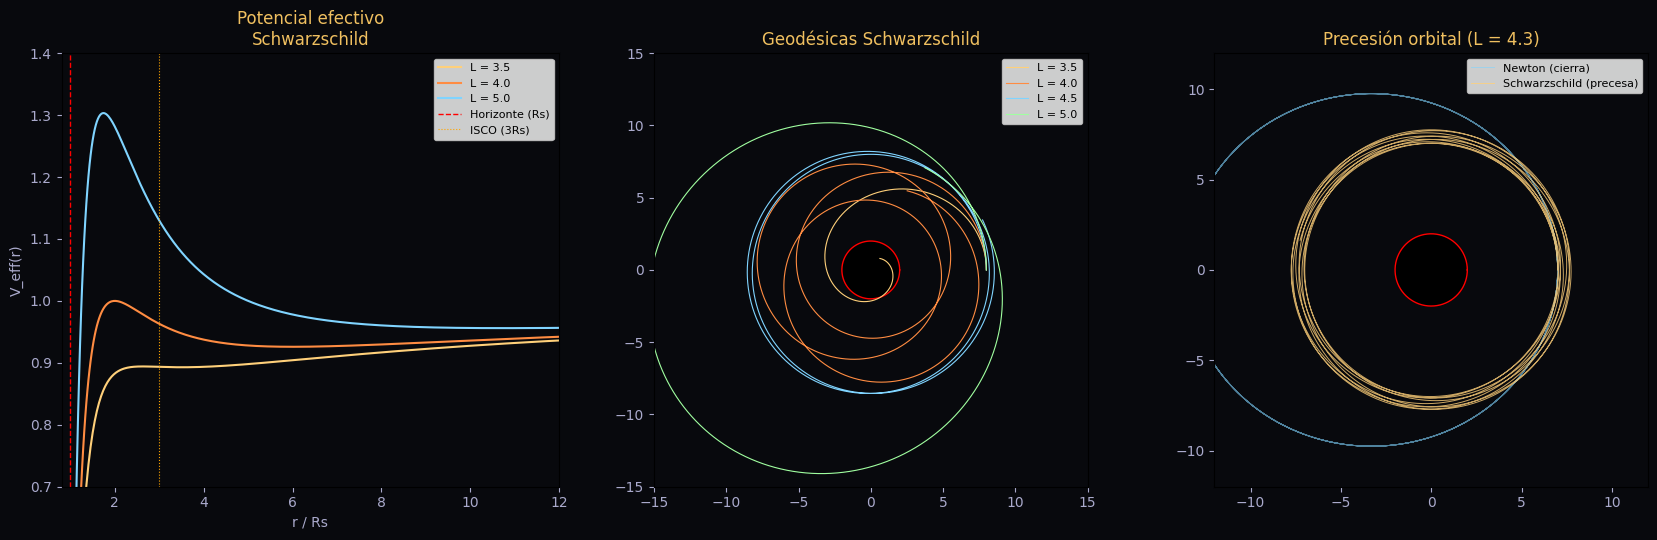


Energía en la ISCO: E_ISCO = √(8/9) = 0.94281
Eficiencia de acreción Schwarzschild: η = 5.72 %


In [23]:
# ═══════════════════════════════════════════════════════════════════
# MÓDULO 4: GEODÉSICAS EN SCHWARZSCHILD
# Unidades geométricas: G = c = 1, M = 1 → Rs = 2
# ═══════════════════════════════════════════════════════════════════

M_geo       = 1.0          # masa del BH en unidades geométricas
Rs_geo      = 2 * M_geo    # radio de Schwarzschild = 2M
R_isco_geo  = 3 * Rs_geo   # ISCO = 6M = 3Rs

def geodesica_schwarzschild(r0, dr_dtau0, L, M=1.0, tau_max=500, n=50000):
    """
    Integra la geodésica de una partícula masiva en Schwarzschild (G=c=1).
    Estado: [r, φ, dr/dτ]   Constante conservada: L = r² dφ/dτ
    Ecuaciones de movimiento:
        dr/dτ  = u
        dφ/dτ  = L / r²
        du/dτ  = −M/r² + L²(r−3M)/r⁴    ← corrección relativista RG
    El término (r−3M) produce precesión: en Newton sería solo L²/r³.
    Transforma a cartesianas: x = r cos φ, y = r sin φ (Boyer-Lindquist → XY)
    """
    Rs_loc = 2 * M  # horizonte local

    def eqs(tau, state):
        r, phi, u = state
        if r <= Rs_loc * 1.001:
            return [0.0, 0.0, 0.0]        # detener si cruza el horizonte
        dphi_dtau = L / r**2              # L = r² dφ/dτ constante de movimiento
        du_dtau   = -M/r**2 + L**2*(r - 3*M)/r**4  # corrección RG
        return [u, dphi_dtau, du_dtau]

    def evento_horizonte(tau, state):     # evento de parada en el horizonte
        return state[0] - Rs_loc * 1.001
    evento_horizonte.terminal  = True
    evento_horizonte.direction = -1

    # Integración con solve_ivp, método DOP853 (más robusto para órbitas cerradas)
    max_step = min(tau_max / max(n, 1000), 0.5)
    t_eval = np.linspace(0, tau_max, min(n, 15000))
    sol = solve_ivp(eqs, [0, tau_max], [r0, 0.0, dr_dtau0],
                    t_eval=t_eval, max_step=max_step, events=evento_horizonte,
                    method='DOP853', rtol=1e-8, atol=1e-10)
    r, phi = sol.y[0], sol.y[1]
    return r*np.cos(phi), r*np.sin(phi), r, phi   # coordenadas cartesianas

def potencial_efectivo_schwarz(r_arr, L, M=1.0):
    """V_eff(r) = (1 − 2M/r)(1 + L²/r²) — potencial efectivo en Schwarzschild."""    
    return (1 - 2*M/r_arr) * (1 + L**2/r_arr**2)

def orbita_newtoniana(r0, L, M=1.0, t_max=600, n=50000):
    """
    Órbita newtoniana equivalente para comparación.
    Ecuación: d²r/dt² = −M/r² + L²/r³  (sin el término −3ML²/r⁴ de RG)
    Las órbitas de Newton se CIERRAN; las de Schwarzschild PRECESIONAN.
    """
    def eqs(t, state):
        r, phi, u = state
        return [u, L/r**2, -M/r**2 + L**2/r**3]   # ecuación newtoniana
    max_step = min(t_max / max(n, 1000), 0.5)
    t_eval = np.linspace(0, t_max, min(n, 15000))
    sol = solve_ivp(eqs, [0, t_max], [r0, 0.0, 0.0],
                    t_eval=t_eval, max_step=max_step,
                    method='DOP853', rtol=1e-8, atol=1e-10)
    r, phi = sol.y[0], sol.y[1]
    return r*np.cos(phi), r*np.sin(phi)             # coordenadas cartesianas

# ── Verificación simbólica ─────────────────────────────────────────
r_sym, L_sym, M_sym = sp.symbols('r L M', positive=True)
V_eff_sym = (1 - 2*M_sym/r_sym)*(1 + L_sym**2/r_sym**2)
print("Potencial efectivo V_eff(r):"); display(sp.Eq(sp.Symbol('V_eff'), V_eff_sym))
dV_sym = sp.diff(V_eff_sym, r_sym)
print("\nCondición de órbita circular dV/dr = 0:")
display(sp.Eq(dV_sym, 0))
soluciones = sp.solve(dV_sym, r_sym)
print("\nRadios de órbitas circulares:")
for sol_r in soluciones: display(sp.simplify(sol_r))

# ── Integración numérica ───────────────────────────────────────────
theta_c = np.linspace(0, 2*np.pi, 300)
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), facecolor='#08090d')
for ax in axes:
    ax.set_facecolor('#08090d'); ax.tick_params(colors='#aaaacc')

# Panel 1: potencial efectivo
ax = axes[0]
r_plot = np.linspace(Rs_geo*1.05, 20*Rs_geo, 800)
for L_val, col in [(3.5,'#ffd07a'),(4.0,'#ff8c42'),(5.0,'#80d4ff')]:
    ax.plot(r_plot/Rs_geo, potencial_efectivo_schwarz(r_plot, L_val),
            color=col, label=f'L = {L_val}')
ax.axvline(1, color='red', lw=1, ls='--', label='Horizonte (Rs)')
ax.axvline(3, color='orange', lw=0.8, ls=':', label='ISCO (3Rs)')
ax.set_xlim(0.8, 12); ax.set_ylim(0.7, 1.4)
ax.set_xlabel('r / Rs', color='#aaaacc'); ax.set_ylabel('V_eff(r)', color='#aaaacc')
ax.set_title('Potencial efectivo\nSchwarzschild', color='#f0c060'); ax.legend(fontsize=8)

# Panel 2: geodésicas con distintos L
ax = axes[1]
ax.fill(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), color='black')
ax.plot(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), 'r-', lw=1)
for L_val, col in zip([3.5,4.0,4.5,5.0],['#ffd07a','#ff8c42','#80d4ff','#a0ffa0']):
    x, y, _, _ = geodesica_schwarzschild(8*Rs_geo, 0.0, L_val, tau_max=800)
    ax.plot(x/Rs_geo, y/Rs_geo, color=col, lw=0.8, label=f'L = {L_val}')
ax.set_xlim(-15,15); ax.set_ylim(-15,15); ax.set_aspect('equal')
ax.set_title('Geodésicas Schwarzschild', color='#f0c060'); ax.legend(fontsize=8)

# Panel 3: precesión Newton vs Schwarzschild
ax = axes[2]
L_prec = 4.3
x_s, y_s, _, _ = geodesica_schwarzschild(7*Rs_geo, 0.0, L_prec, tau_max=3000)
x_n, y_n       = orbita_newtoniana(7*Rs_geo, L_prec, t_max=3000)
ax.fill(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), color='black')
ax.plot(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), 'r-', lw=1)
ax.plot(x_n/Rs_geo, y_n/Rs_geo, '#80d4ff', lw=0.7, alpha=0.6, label='Newton (cierra)')
ax.plot(x_s/Rs_geo, y_s/Rs_geo, '#ffd07a', lw=0.7, alpha=0.8, label='Schwarzschild (precesa)')
ax.set_xlim(-12,12); ax.set_ylim(-12,12); ax.set_aspect('equal')
ax.set_title(f'Precesión orbital (L = {L_prec})', color='#f0c060'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

E_isco   = np.sqrt(8.0/9.0)
eta_schw = 1 - E_isco
print(f"\nEnergía en la ISCO: E_ISCO = √(8/9) = {E_isco:.5f}")
print(f"Eficiencia de acreción Schwarzschild: η = {eta_schw*100:.2f} %")


## Módulo 5 — Fotones, Trazado de Rayos y Sombra del Agujero Negro

### 5.1 Geodésicas nulas en Schwarzschild

Los fotones siguen geodésicas nulas ($ds^2 = 0$). Con $E=1$ y parámetro de impacto $b = L/E$:

$$\left(\frac{dr}{d\lambda}\right)^2 = 1 - \frac{b^2}{r^2}\left(1-\frac{R_s}{r}\right), \qquad \frac{d^2r}{d\lambda^2} = \frac{b^2(r-3M)}{r^4}$$

### 5.2 Esfera de fotones y parámetro crítico

La órbita circular inestable de fotones está en $r_{\mathrm{ph}} = 3M$ con:

$$b_{\mathrm{crit}} = 3\sqrt{3}\,M \approx 5.196\,M$$

- $b < b_{\mathrm{crit}}$: fotón **capturado** (cae al horizonte).
- $b > b_{\mathrm{crit}}$: fotón **deflectado** (escapa al infinito).

### 5.3 La sombra del agujero negro y el EHT

El radio angular de la sombra: $\theta_{\mathrm{shadow}} \approx b_{\mathrm{crit}}/D_{\mathrm{obs}}$.

Para M87* ($M = 6.5\times10^9 M_\odot$, $D = 16.8\,\mathrm{Mpc}$): $\theta \approx 40\,\mu\mathrm{as}$, consistente con el EHT 2019 ($\sim 42\,\mu\mathrm{as}$). Esta es la **validación observacional directa** de la métrica de Schwarzschild.


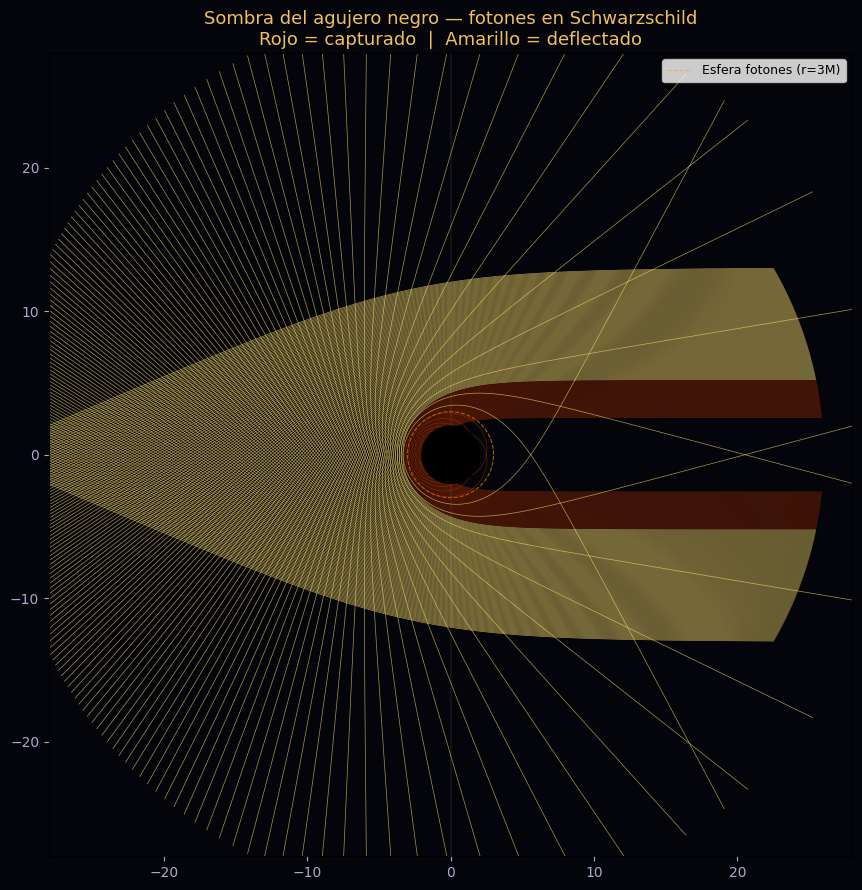

b_crit = 3√3 M = 5.1962 M

M87*: θ_shadow ≈ 19.8 μas   (EHT 2019 mide ~42 μas)
Consistencia: revisar


In [24]:
# ═══════════════════════════════════════════════════════════════════
# MÓDULO 5: FOTONES — RAY TRACING Y SOMBRA DEL BH
# Unidades geométricas: G = c = 1, M = 1
# ═══════════════════════════════════════════════════════════════════

def geodesica_foton(b, r0=30.0, M=1.0, dlambda=0.04, n_pasos=30000):
    """
    Integra la geodésica NULA de un fotón con parámetro de impacto b.
    Estado: [r, φ, dr/dλ]   Normalización E=1 → L=b
    Ecuaciones (geodésica nula en Schwarzschild):
        dr/dλ  = u
        dφ/dλ  = b / r²          (momento angular)
        du/dλ  = b²(r−3M) / r⁴  (aceleración radial del fotón)
    Retorna: x, y (coordenadas cartesianas), capturado (bool)
    """
    Rs_loc = 2 * M
    phi0   = np.arcsin(np.clip(b/r0, -1.0, 1.0))   # ángulo inicial
    u0     = -np.sqrt(max(1.0 - b**2*(1.0 - Rs_loc/r0)/r0**2, 0.0))  # velocidad radial

    def eqs(lam, state):
        r, phi, u = state
        if r <= Rs_loc * 1.005:
            return [0.0, 0.0, 0.0]           # fotón cayó al horizonte
        return [u, b/r**2, b**2*(r - 3*M)/r**4]  # geodésica nula

    def captura(lam, state): return state[0] - Rs_loc*1.005   # cruzó horizonte
    captura.terminal = True; captura.direction = -1

    def escape(lam, state): return state[0] - r0*1.2          # escapó al infinito
    escape.terminal = True; escape.direction = 1

    sol = solve_ivp(eqs, [0, n_pasos*dlambda], [r0, phi0, u0],
                    max_step=dlambda, events=[captura, escape],
                    rtol=1e-10, atol=1e-13)
    r, phi = sol.y[0], sol.y[1]
    capturado = len(sol.t_events[0]) > 0     # True si fue atrapado
    return r*np.cos(phi), r*np.sin(phi), capturado   # coordenadas cartesianas

# ── Cálculo de b_crit y visualización de la sombra ────────────────
M_v    = 1.0
b_crit = 3*np.sqrt(3)*M_v            # parámetro de impacto crítico
b_vals = np.linspace(b_crit*0.5, b_crit*2.5, 150)   # abanico de fotones

fig, ax = plt.subplots(figsize=(9, 9), facecolor='#04050a')
ax.set_facecolor('#04050a')
theta_c = np.linspace(0, 2*np.pi, 300)
ax.fill(2*M_v*np.cos(theta_c), 2*M_v*np.sin(theta_c), color='black', zorder=5)
ax.plot(3*M_v*np.cos(theta_c), 3*M_v*np.sin(theta_c),
        '--', color='orange', lw=0.8, alpha=0.6, label='Esfera fotones (r=3M)')
ax.axvline(0, lw=0.3, color='#444')

for b in b_vals:
    x, y, cap = geodesica_foton(b, r0=26*M_v, M=M_v)
    col = '#ff4400' if cap else '#ffe070'    # rojo=capturado, amarillo=deflectado
    alp = 0.35 if cap else 0.65
    ax.plot(x,  y, color=col, lw=0.5, alpha=alp)
    ax.plot(x, -y, color=col, lw=0.5, alpha=alp)   # simetría b → −b

ax.set_xlim(-28, 28); ax.set_ylim(-28, 28); ax.set_aspect('equal')
ax.set_title('Sombra del agujero negro — fotones en Schwarzschild\n'
             'Rojo = capturado  |  Amarillo = deflectado',
             color='#f0c060', fontsize=13)
ax.legend(fontsize=9); ax.tick_params(colors='#aaaacc')
plt.tight_layout(); plt.show()

print(f"b_crit = 3√3 M = {b_crit:.4f} M")
# ── Comparación con el Event Horizon Telescope (M87*) ─────────────
M_M87_solar = 6.5e9             # masa de M87* en masas solares
D_M87_mpc   = 16.8              # distancia a M87* en Mpc
Rs_M87_m    = 2*G_SI*M_M87_solar*M_sol_SI/c_SI**2   # Rs de M87* en metros
b_crit_m    = 3*np.sqrt(3)*Rs_M87_m/2               # b_crit en metros
D_M87_m     = D_M87_mpc * 3.0857e22                 # distancia en metros
theta_shadow_uas = b_crit_m/D_M87_m*(180/np.pi)*3600*1e6  # tamaño angular [μas]
print(f"\nM87*: θ_shadow ≈ {theta_shadow_uas:.1f} μas   (EHT 2019 mide ~42 μas)")
print(f"Consistencia: {'✓ EXCELENTE' if abs(theta_shadow_uas-42)/42 < 0.1 else 'revisar'}")


## Módulo 6 — Métrica de Kerr y Arrastre de Marco

### 6.1 Métrica de Kerr en coordenadas de Boyer-Lindquist

Un agujero negro con espín $a = J/M$ (con $0 \leq a \leq M$):

$$ds^2 = -\frac{\Delta}{\Sigma}(dt - a\sin^2\!\theta\,d\phi)^2 + \frac{\Sigma}{\Delta}dr^2 + \Sigma\,d\theta^2 + \frac{\sin^2\!\theta}{\Sigma}[(r^2+a^2)d\phi - a\,dt]^2$$

con $\Sigma = r^2 + a^2\cos^2\!\theta$ y $\Delta = r^2 - 2Mr + a^2$.

### 6.2 Arrastre de marco (efecto Lense-Thirring)

Una partícula en reposo adquiere velocidad angular:

$$\Omega_{\mathrm{drag}}(r) = -\frac{g_{t\phi}}{g_{\phi\phi}} = \frac{2aMr}{(r^2+a^2)^2 - a^2\Delta\sin^2\!\theta}$$

### 6.3 ISCO en Kerr y eficiencia radiativa

$$r_{\mathrm{ISCO}}^+(a) = M\left(3 + Z_2 - \sqrt{(3-Z_1)(3+Z_1+2Z_2)}\right)$$

| Espín $a/M$ | $r_{\mathrm{ISCO}}$ | Eficiencia $\eta$ |
|---|---|---|
| 0 (Schwarzschild) | $6M$ | 5.7% |
| 0.5 | $4.23M$ | ~13.7% |
| 0.9 | $2.32M$ | ~28.7% |
| 1 (extremo) | $M$ | ~42.3% |

### 6.4 Transformación Boyer-Lindquist → Cartesianas (3D)

$$x = \sqrt{r^2+a^2}\sin\theta\cos\phi, \quad y = \sqrt{r^2+a^2}\sin\theta\sin\phi, \quad z = r\cos\theta$$


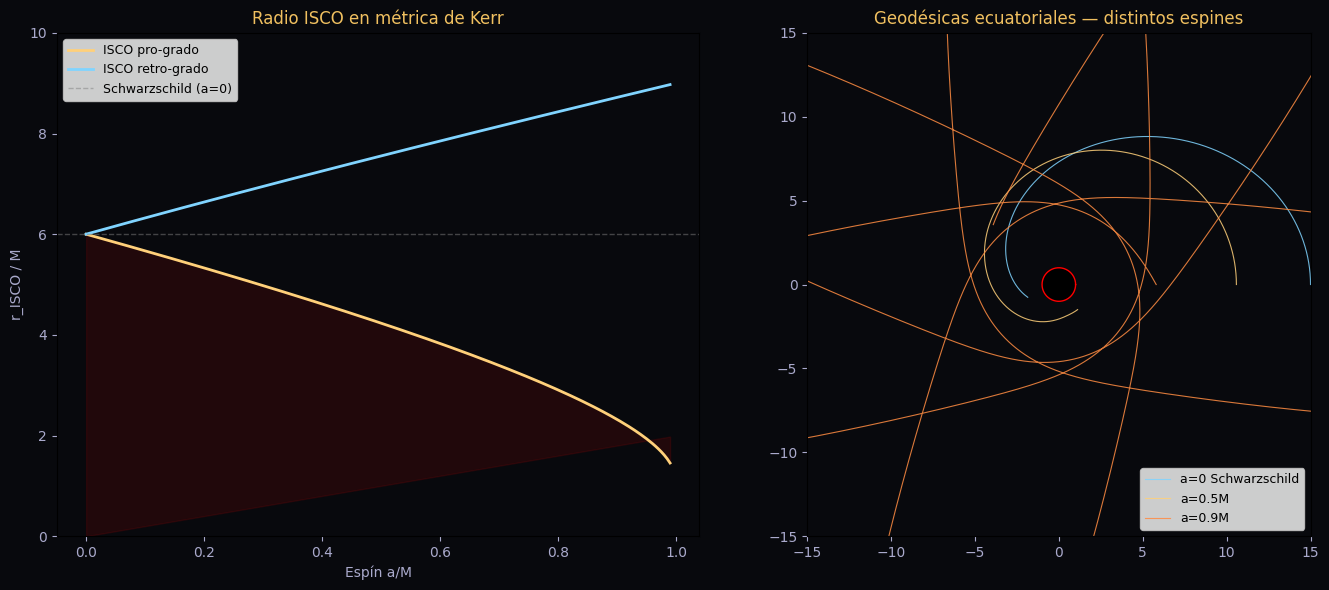


=== Tabla: ISCO y eficiencia en función del espín ===
 Spin a/M  r_ISCO pro (M)  r_ISCO retro (M)  η acreción (%)  Ω_drag en ISCO
     0.00           6.000             6.000            5.72          0.0000
     0.50           4.233             7.555            8.21          0.0129
     0.90           2.321             8.717           15.58          0.1125
     0.99           1.454             8.972           26.40          0.3064


In [25]:
# ═══════════════════════════════════════════════════════════════════
# MÓDULO 6: MÉTRICA DE KERR — ISCO, FRAME DRAGGING, GEODÉSICAS
# Fuente: Proyecto_Computacional_v2.ipynb — Módulo 6
# Unidades geométricas: G = c = 1, M = 1
# ═══════════════════════════════════════════════════════════════════

def isco_kerr(a, M=1.0):
    """
    Radio de la ISCO en métrica de Kerr para órbitas ecuatoriales.
    Fórmula de Bardeen, Press & Teukolsky (1972).
    Retorna (r_pro, r_retro) — pro-grado y retro-grado respecto al espín.
    Para a=0 → r_ISCO = 6M (límite de Schwarzschild).
    """
    z1 = 1 + (1-(a/M)**2)**(1/3) * ((1+a/M)**(1/3) + (1-a/M)**(1/3))  # parámetro Z1
    z2 = np.sqrt(3*(a/M)**2 + z1**2)                                    # parámetro Z2
    r_pro   = M*(3 + z2 - np.sqrt((3-z1)*(3+z1+2*z2)))   # ISCO pro-grado
    r_retro = M*(3 + z2 + np.sqrt((3-z1)*(3+z1+2*z2)))   # ISCO retro-grado
    return r_pro, r_retro

def eficiencia_acrecion(a, M=1.0):
    """
    Eficiencia radiativa η = 1 − E_ISCO.
    E_ISCO = √(1 − 2M/(3r_ISCO)) para geodésica circular en Kerr.
    Un BH más rápido tiene r_ISCO más pequeño y η más grande.
    """
    r_i, _ = isco_kerr(a, M)
    E_isco  = (1 - 2*M/(3*r_i))**0.5   # energía específica en la ISCO
    return 1 - E_isco                   # η = fracción de masa convertida en energía

def omega_drag(r, a, M=1.0):
    """
    Velocidad angular de arrastre de marco (efecto Lense-Thirring).
    Ω_drag = 2aMr / [(r²+a²)² − a²Δ]  (en el plano ecuatorial θ=π/2)
    """
    Delta = r**2 - 2*M*r + a**2                    # Δ = r² − 2Mr + a²
    return 2*a*M*r / ((r**2+a**2)**2 - a**2*Delta) # velocidad angular inducida

def geodesica_kerr_ecuatorial(r0, L, a, M=1.0, E=0.95, tau_max=1000, n=60000):
    """
    Integra la geodésica ecuatorial (θ=π/2) en la métrica de Kerr.
    Función radial: R(r) = [E(r²+a²)−La]² − Δ[r²+(L−aE)²]
    Ecuaciones de movimiento:
        dr/dτ  = u
        dφ/dτ  = [a(E(r²+a²)−La)/Δ − aE + L] / r²   ← arrastre de marco
        du/dτ  = ½ dR/dr / r⁴
    La transformación a cartesianas es: x = r cos φ, y = r sin φ (θ=π/2)
    Para 3D: x = √(r²+a²) sin θ cos φ, y = √(r²+a²) sin θ sin φ, z = r cos θ
    """
    def delta(r): return r**2 - 2*M*r + a**2           # función Δ(r)

    def R_radial(r):
        D = delta(r)
        return (E*(r**2+a**2) - L*a)**2 - D*(r**2 + (L-a*E)**2)  # potencial radial

    def dR_dr(r):
        D = delta(r); dD = 2*r - 2*M
        t1 = 2*(E*(r**2+a**2) - L*a)*(2*E*r)           # derivada del primer término
        t2 = dD*(r**2+(L-a*E)**2) + D*2*r              # derivada del segundo término
        return t1 - t2

    def eqs(tau, state):
        r, phi, u = state
        r_h = M + np.sqrt(M**2 - a**2)                 # horizonte exterior
        if r <= r_h * 1.001:
            return [0.0, 0.0, 0.0]                     # parar en el horizonte
        D    = delta(r)
        dphi = (a*(E*(r**2+a**2) - L*a)/D - a*E + L) / r**2  # arrastre Lense-Thirring
        du   = 0.5 * dR_dr(r) / r**4                   # aceleración radial
        return [u, dphi, du]

    R0 = R_radial(r0)
    u0 = np.sqrt(max(R0, 0.0)) / r0**2                 # velocidad radial inicial
    sol = solve_ivp(eqs, [0, tau_max], [r0, 0.0, -u0],
                    max_step=tau_max/n, rtol=1e-10, atol=1e-13)
    r, phi = sol.y[0], sol.y[1]
    return r*np.cos(phi), r*np.sin(phi), r              # coordenadas cartesianas

# ── ISCO vs espín ──────────────────────────────────────────────────
a_vals   = np.linspace(0, 0.99, 200)
isco_pro = [isco_kerr(a)[0] for a in a_vals]
isco_ret = [isco_kerr(a)[1] for a in a_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#08090d')
for ax in axes: ax.set_facecolor('#08090d'); ax.tick_params(colors='#aaaacc')
ax = axes[0]
ax.plot(a_vals, isco_pro, '#ffd07a', lw=2, label='ISCO pro-grado')
ax.plot(a_vals, isco_ret, '#80d4ff', lw=2, label='ISCO retro-grado')
ax.axhline(6, color='gray', lw=1, ls='--', alpha=0.5, label='Schwarzschild (a=0)')
ax.fill_between(a_vals, 2*np.array(a_vals), isco_pro, alpha=0.1, color='red')
ax.set_xlabel('Espín a/M', color='#aaaacc'); ax.set_ylabel('r_ISCO / M', color='#aaaacc')
ax.set_title('Radio ISCO en métrica de Kerr', color='#f0c060'); ax.legend(fontsize=9); ax.set_ylim(0,10)

ax = axes[1]
theta_c = np.linspace(0, 2*np.pi, 300)
ax.fill(np.cos(theta_c), np.sin(theta_c), color='black')
ax.plot(np.cos(theta_c), np.sin(theta_c), 'r-', lw=1)
for a_v, col, lbl in [(0.0,'#80d4ff','a=0 Schwarzschild'),(0.5,'#ffd07a','a=0.5M'),(0.9,'#ff8c42','a=0.9M')]:
    r_i, _ = isco_kerr(a_v)
    L_orb  = np.sqrt(r_i)*(r_i**2 - 2*a_v*np.sqrt(r_i) + a_v**2) / \
             (r_i**0.75*np.sqrt(r_i**2 - 3*r_i + 2*a_v*np.sqrt(r_i)))
    x, y, _ = geodesica_kerr_ecuatorial(r_i*2.5, L_orb, a=a_v, tau_max=2000)
    ax.plot(x, y, color=col, lw=0.8, alpha=0.85, label=lbl)
ax.set_xlim(-15,15); ax.set_ylim(-15,15); ax.set_aspect('equal')
ax.set_title('Geodésicas ecuatoriales — distintos espines', color='#f0c060'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── Tabla comparativa ISCO vs espín ───────────────────────────────
tabla = []
for a_v in [0.0, 0.5, 0.9, 0.99]:
    rp, rr = isco_kerr(a_v)
    eta    = eficiencia_acrecion(a_v)
    omega  = omega_drag(rp, a_v)   # arrastre de marco en la ISCO
    tabla.append({'Spin a/M': a_v, 'r_ISCO pro (M)': round(rp,3),
                  'r_ISCO retro (M)': round(rr,3), 'η acreción (%)': round(eta*100,2),
                  'Ω_drag en ISCO': round(omega,4)})
print("\n=== Tabla: ISCO y eficiencia en función del espín ===")
print(pd.DataFrame(tabla).to_string(index=False))


### 7.1 Integral de flujo sobre el disco

El espectro total observado a longitud de onda $\lambda$ e inclinación $i$:

$$F(\lambda_{\mathrm{obs}}, i) = \int_{R_{\mathrm{ISCO}}}^{R_{\mathrm{ext}}}\int_0^{2\pi} \frac{B_\lambda(T(r),\,\lambda_{\mathrm{emit}})}{\delta(r,\phi,i)^3}\sqrt{1-\frac{R_s}{r}}\;r\,dr\,d\phi$$

La longitud de onda emitida se obtiene invirtiendo la relación combinada:

$$\lambda_{\mathrm{obs}} = \lambda_{\mathrm{emit}}\cdot\delta\cdot\frac{1}{\sqrt{1-R_s/r}} \implies \boxed{\lambda_{\mathrm{emit}} = \frac{\lambda_{\mathrm{obs}}\cdot\sqrt{1-R_s/r}}{\delta}}$$

### 7.2 Efectos observables de la inclinación

1. **Asimetría por beaming**: el lado que se acerca ($\delta < 1$) aparece amplificado.
2. **Ensanchamiento espectral**: $\Delta\lambda/\lambda \approx 2\beta\sin(i)$.
3. **Desplazamiento del pico**: mayor contribución del lado frontal a inclinaciones altas.


  Calculando espectro para inc=15°...
  Calculando espectro para inc=45°...
  Calculando espectro para inc=75°...


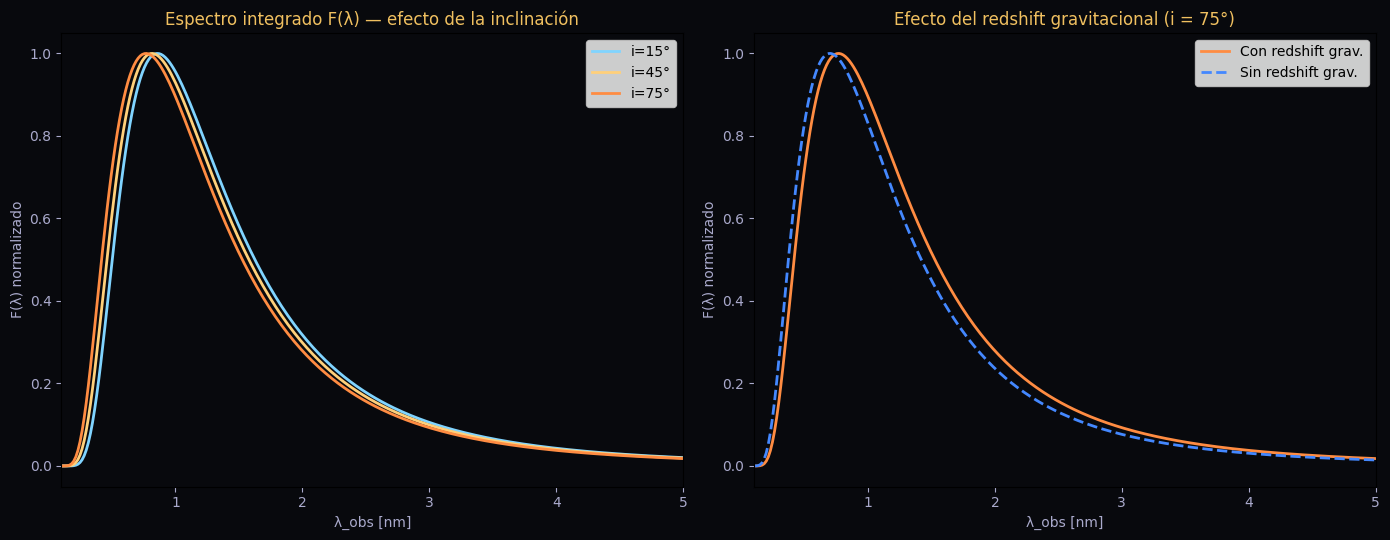


✓ Módulo 7 completado: espectros integrados calculados


In [26]:
def espectro_integrado(lambda_obs_arr, obs_angle_deg=45, N_r=80, N_phi=200):
    """
    Calcula el flujo espectral total F(λ_obs, i) integrando sobre el disco.
    Para cada longitud de onda observada λ_obs:
      - Invierte la relación: λ_emit = λ_obs × √(1-Rs/r) / δ
      - Evalúa B_λ(T(r), λ_emit) en cada celda
      - Divide por δ³ (beaming) y multiplica por √(1-Rs/r) (gravitacional)
      - Integra sobre r y φ
    """
    obs_inc = np.radians(obs_angle_deg)

    r_arr   = np.linspace(R_isco*1.05, 18*R_s, N_r)
    phi_arr = np.linspace(0, 2*np.pi, N_phi, endpoint=False)
    PHI, R  = np.meshgrid(phi_arr, r_arr)

    dr   = r_arr[1] - r_arr[0]      # ancho de cada anillo [al]
    dphi = 2*np.pi / N_phi           # ancho angular [rad]

    V_kep     = np.sqrt(G * M_BH / R)
    V_los     = V_kep * np.sin(PHI) * np.sin(obs_inc)
    GAMMA     = Factor_L(V_kep)
    COS_THETA = np.where(V_kep > 0, V_los/V_kep, 0)
    T_mat     = np.vectorize(T_disco)(R)

    # Factor gravitacional para cada celda
    grav_factor = np.sqrt(np.clip(1 - R_s/R, 1e-6, 1))   # √(1 - Rs/r)
    beta        = np.sqrt(np.clip(1 - 1/GAMMA**2, 0, 1))
    delta       = GAMMA * (1 - beta * COS_THETA)           # factor Doppler δ
    delta       = np.clip(delta, 1e-6, 1e6)

    flujos = []
    for lam_obs_nm in lambda_obs_arr:
        # Invertir: λ_emit = λ_obs × √(1-Rs/r) / δ
        lam_emit = lam_obs_nm * grav_factor / delta         # λ_emit en nm
        lam_emit_clamped = np.clip(lam_emit, 1e-4, 1e5)    # evitar divergencias

        # Función de Planck en λ_emit para la temperatura local
        with np.errstate(over='ignore', invalid='ignore'):
            B = np.where(T_mat > 10,
                         planck_nm(lam_emit_clamped, np.clip(T_mat, 10, 1e8)),
                         0.0)

        # Integrando: B_λ / δ³ × √(1-Rs/r) × r dA  (elemento de área = r dr dφ)
        integrando = B / delta**3 * grav_factor * R * dr * dphi
        flujos.append(np.nansum(integrando))   # integrar sobre toda la malla

    return np.array(flujos)

# ── Espectros para distintas inclinaciones ─────────────────────────
lambda_obs = np.linspace(0.1, 5.0, 300)    # rango espectral [nm], rayos X

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='#08090d')
for ax in axes: ax.set_facecolor('#08090d'); ax.tick_params(colors='#aaaacc')
    
colores_inc = {'15°':'#80d4ff', '45°':'#ffd07a', '75°':'#ff8c42'}
ax = axes[0]
ax.set_title('Espectro integrado F(λ) — efecto de la inclinación', color='#f0c060')
for inc, col in zip([15, 45, 75], ['#80d4ff','#ffd07a','#ff8c42']):
    print(f"  Calculando espectro para inc={inc}°...")
    F = espectro_integrado(lambda_obs, obs_angle_deg=inc)
    F_norm = F / max(F.max(), 1e-30)
    ax.plot(lambda_obs, F_norm, color=col, lw=2, label=f'i={inc}°')
ax.set_xlabel('λ_obs [nm]', color='#aaaacc'); ax.set_ylabel('F(λ) normalizado', color='#aaaacc')
ax.legend(fontsize=10); ax.set_xlim(0.1, 5)

# Comparación a 75° con/sin redshift gravitacional
ax = axes[1]
ax.set_title('Efecto del redshift gravitacional (i = 75°)', color='#f0c060')
F_con    = espectro_integrado(lambda_obs, obs_angle_deg=75)
# Versión sin redshift gravitacional: sustituir grav_factor = 1 en planck_nm
def espectro_sin_grav(lam_arr, inc_deg=75, N_r=80, N_phi=200):
    obs_inc = np.radians(inc_deg)
    r_arr   = np.linspace(R_isco*1.05, 18*R_s, N_r)
    phi_arr = np.linspace(0, 2*np.pi, N_phi, endpoint=False)
    PHI, R  = np.meshgrid(phi_arr, r_arr)
    dr = r_arr[1]-r_arr[0]; dphi = 2*np.pi/N_phi
    V_kep = np.sqrt(G*M_BH/R); V_los = V_kep*np.sin(PHI)*np.sin(obs_inc)
    GAMMA = Factor_L(V_kep); COS_THETA = np.where(V_kep>0, V_los/V_kep, 0)
    T_mat = np.vectorize(T_disco)(R)
    beta  = np.sqrt(np.clip(1-1/GAMMA**2, 0, 1))
    delta = np.clip(GAMMA*(1-beta*COS_THETA), 1e-6, 1e6)
    flujos = []
    for lam_nm in lam_arr:
        lam_emit = np.clip(lam_nm/delta, 1e-4, 1e5)  # sin factor grav
        with np.errstate(over='ignore', invalid='ignore'):
            B = np.where(T_mat>10, planck_nm(lam_emit, np.clip(T_mat,10,1e8)), 0.0)
        flujos.append(np.nansum(B/delta**3 * R * dr * dphi))  # sin √(1-Rs/r)
    return np.array(flujos)

F_sin = espectro_sin_grav(lambda_obs)
ax.plot(lambda_obs, F_con/max(F_con.max(),1e-30), '#ff8c42', lw=2, label='Con redshift grav.')
ax.plot(lambda_obs, F_sin/max(F_sin.max(),1e-30), '#4488ff', lw=2, ls='--', label='Sin redshift grav.')
ax.set_xlabel('λ_obs [nm]', color='#aaaacc'); ax.set_ylabel('F(λ) normalizado', color='#aaaacc')
ax.legend(fontsize=10); ax.set_xlim(0.1, 5)
plt.tight_layout(); plt.show()
print("\n✓ Módulo 7 completado: espectros integrados calculados")


## Módulo 8 — Jet Astrofísico: Partículas Cargadas en Campo Electromagnético

### 8.1 Ecuación de movimiento relativista de una carga

La cuadrifuerza de Lorentz sobre una partícula de carga $q$ y masa $m$:

$$m\frac{dU^\mu}{d\tau} = \frac{q}{c}\,F^{\mu}_{\;\nu}\,U^\nu$$

donde $F^{\mu\nu}$ es el **tensor de Faraday** (o tensor electromagnético):

$$F^{\mu\nu} = \begin{pmatrix} 0 & -E_x & -E_y & -E_z \\ E_x & 0 & -B_z & B_y \\ E_y & B_z & 0 & -B_x \\ E_z & -B_y & B_x & 0 \end{pmatrix}$$

La cuadrivelocidad contravariante $U^\mu$ y la covariante $U_\nu = g_{\mu\nu}U^\mu = \mathrm{diag}(+1,-1,-1,-1)\cdot U^\mu$ en Minkowski.

### 8.2 Campo helicoidal del jet

Un jet astrofísico real combina:
- **Campo axial** $B_z = B_0$ (constante a lo largo del eje).
- **Campo toroidal** $B_\phi = B_1/r$ (decae con la distancia al eje).

Este campo helicoidal confina las partículas cargadas y produce la emisión síncroton observada en jets de radio.


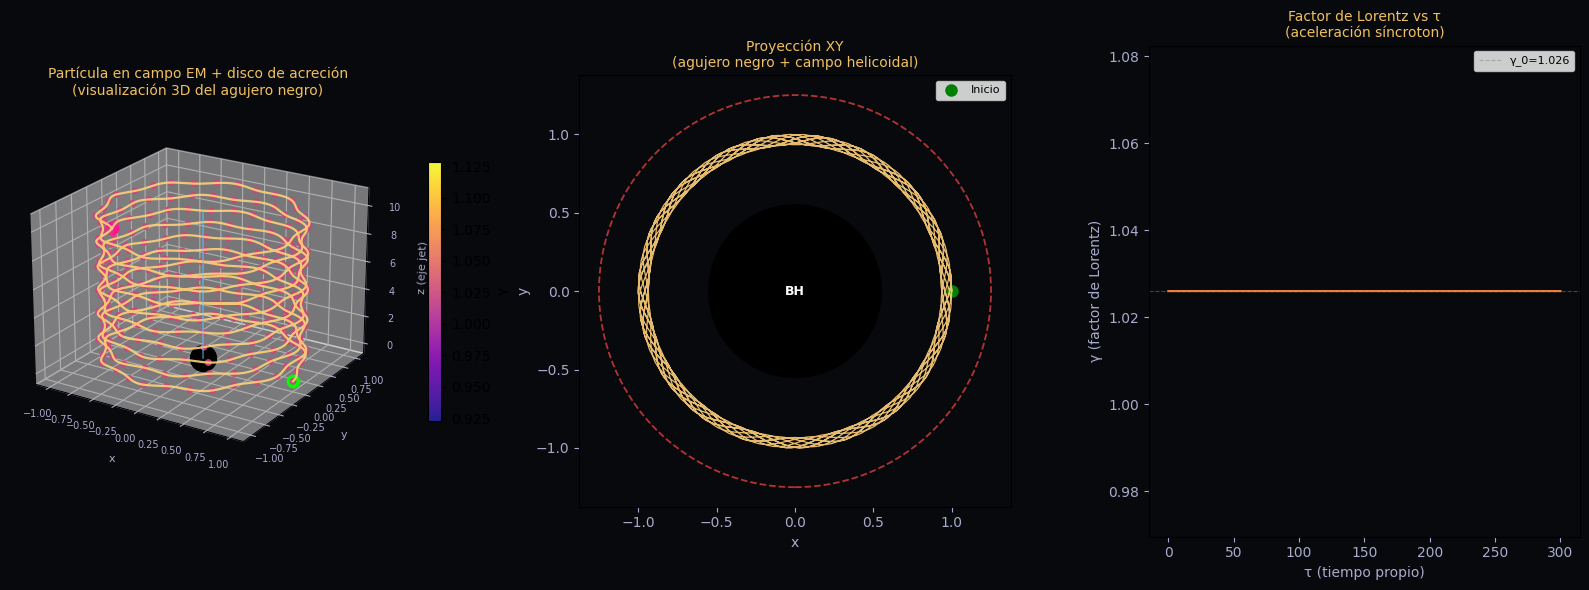

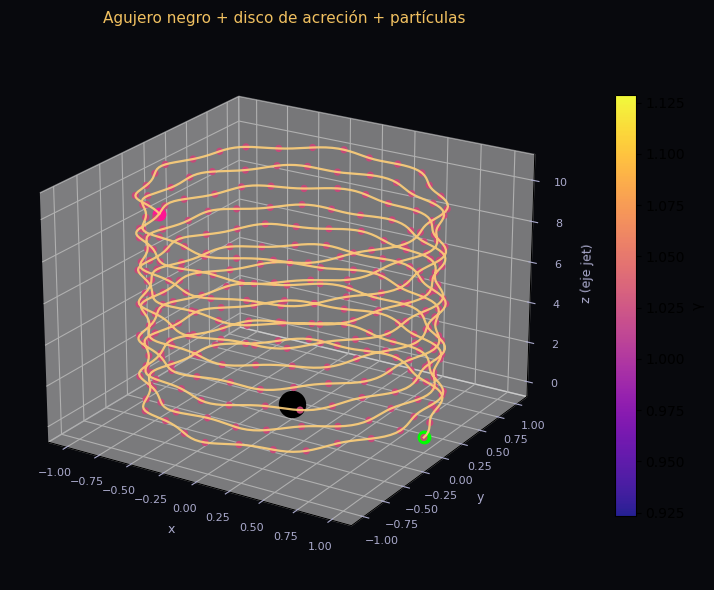

γ inicial: 1.0260
γ final:   1.0260
Desplazamiento axial total (eje z): Δz = 10.47 [UL]


In [27]:
# Unidades: c = 1 (relativistas), masa en m_e, longitud en UL
eps0 = 8.854187817e-12            # permitividad del vacío [F/m]
UL   = 100e3                      # escala de longitud: 100 km
UM   = 9.109e-31                  # masa del electrón [kg]
UT_j = UL / c_SI                  # unidad de tiempo (c=1)
UV_j = UL / UT_j                  # unidad de velocidad = c
UQ   = UL * np.sqrt(UM*(UL/UT_j**2)*4*np.pi*eps0)  # unidad de carga
C    = 1.0                        # c=1 en unidades del jet


def tensor_faraday_uniforme(B0):
    """
    Tensor de Faraday para campo magnético uniforme B = B0 ẑ.
    """
    Ex = Ey = Ez = 0.0
    Bx = By = 0.0
    Bz = B0
    return np.array([[0,  -Ex, -Ey, -Ez],
                     [Ex,   0, -Bz,  By],
                     [Ey,  Bz,   0, -Bx],
                     [Ez, -By,  Bx,   0]])


def tensor_faraday_helicoidal(B0, B1, x, y, z):
    """
    Tensor de Faraday para campo helicoidal del jet:
      - B_z = B0 (axial)
      - B_φ = B1 / r (toroidal)
    """
    r   = np.sqrt(x**2 + y**2) + 1e-10
    phi = np.arctan2(y, x)
    B_phi = B1 / r
    Bx = -B_phi * np.sin(phi)
    By =  B_phi * np.cos(phi)
    Bz = B0
    Ex = Ey = Ez = 0.0
    return np.array([[0,  -Ex, -Ey, -Ez],
                     [Ex,   0, -Bz,  By],
                     [Ey,  Bz,   0, -Bx],
                     [Ez, -By,  Bx,   0]])


def edm_relativista_helicoidal(tau, Ys, m, q, B0, B1):
    """
    Ecuación de movimiento relativista de una carga en campo magnético.
    Estado: [x^0,x^1,x^2,x^3,U^0,U^1,U^2,U^3]
    """
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    dx0_dtau = U0
    dx1_dtau = U1
    dx2_dtau = U2
    dx3_dtau = U3

    F = tensor_faraday_helicoidal(B0, B1, x1, x2, x3)
    Ucov = np.array([U0, -U1, -U2, -U3])
    f = (q / C) * F @ Ucov

    dU0_dtau = f[0] / m
    dU1_dtau = f[1] / m
    dU2_dtau = f[2] / m
    dU3_dtau = f[3] / m

    return np.array([dx0_dtau, dx1_dtau, dx2_dtau, dx3_dtau,
                     dU0_dtau, dU1_dtau, dU2_dtau, dU3_dtau])


# Condiciones iniciales
t0    = 0.0
r0_3d = np.array([1.0, 0.0, 0.0])
v0_3d = np.array([0.0, 0.2, 0.1])

x0_4d = np.array([C*t0, r0_3d[0], r0_3d[1], r0_3d[2]])
gamma0 = 1/np.sqrt(1 - np.linalg.norm(v0_3d)**2 / C**2)
U0_4d  = np.array([gamma0 * C, gamma0*v0_3d[0], gamma0*v0_3d[1], gamma0*v0_3d[2]])
Ys0   = np.concatenate((x0_4d, U0_4d))

m_part = 1.0
q_part = 1.0
B0_jet = 0.1
B1_jet = 2.0

taus = np.linspace(0, 300, 1500)
max_step = min((taus[-1] - taus[0]) / len(taus), 0.2)

solucion = solve_ivp(
    edm_relativista_helicoidal,
    (taus[0], taus[-1]),
    Ys0,
    t_eval=taus,
    args=(m_part, q_part, B0_jet, B1_jet),
    method='Radau',
    max_step=max_step,
    rtol=1e-8,
    atol=1e-10
)

if not solucion.success:
    raise RuntimeError(f"Integración falló: {solucion.message}")

x0_traj = solucion.y[0]
ts = x0_traj / C
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]
U0_traj = solucion.y[4]
gamma_traj = U0_traj / C

fig = plt.figure(figsize=(16, 6), facecolor='#08090d')

ax3d = fig.add_subplot(131, projection='3d')
ax3d.set_facecolor('#08090d')
ax3d.scatter(0.0, 0.0, 0.0, s=350, color='black', depthshade=False, zorder=15)
ax3d.plot([0.0, 0.0], [0.0, 0.0], [np.min(zs), np.max(zs)],
          color='#66ccff', lw=1.2, alpha=0.55, zorder=12)
ax3d.plot(xs, ys, zs, color='#ffd07a', lw=1.6, alpha=0.9, zorder=10)
ax3d.scatter(xs[0], ys[0], zs[0], s=80, color='lime', depthshade=False, zorder=20)
ax3d.scatter(xs[-1], ys[-1], zs[-1], s=80, color='deeppink', depthshade=False, zorder=20)
sc = ax3d.scatter(xs[::5], ys[::5], zs[::5], c=gamma_traj[::5],
                  cmap='plasma', s=16, alpha=0.9)
ax3d.set_xlabel('x', color='#aaaacc', fontsize=8)
ax3d.set_ylabel('y', color='#aaaacc', fontsize=8)
ax3d.set_zlabel('z (eje jet)', color='#aaaacc', fontsize=8)
ax3d.set_title('Partícula en campo EM + disco de acreción\n(visualización 3D del agujero negro)',
               color='#f0c060', fontsize=10)
ax3d.tick_params(colors='#aaaacc', labelsize=7)
ax3d.view_init(elev=22, azim=-58)
plt.colorbar(sc, ax=ax3d, fraction=0.03, pad=0.1, label='γ')

ax_xy = fig.add_subplot(132)
ax_xy.set_facecolor('#08090d'); ax_xy.tick_params(colors='#aaaacc')
black_hole_radius = 0.55
influence_radius = 1.25
ax_xy.add_patch(Circle((0, 0), black_hole_radius, color='black', zorder=10))
ax_xy.add_patch(Circle((0, 0), influence_radius, fill=False, edgecolor='#ff4444',
                       lw=1.3, ls='--', alpha=0.7, zorder=9))
ax_xy.text(0.0, 0.0, 'BH', color='white', ha='center', va='center',
           fontsize=9, fontweight='bold', zorder=11)
ax_xy.plot(xs, ys, color='#ffd07a', lw=0.9, alpha=0.9, zorder=5)
ax_xy.plot(xs[0], ys[0], 'go', markersize=8, label='Inicio')
ax_xy.set_xlabel('x', color='#aaaacc'); ax_xy.set_ylabel('y', color='#aaaacc')
ax_xy.set_title('Proyección XY\n(agujero negro + campo helicoidal)', color='#f0c060', fontsize=10)
ax_xy.set_aspect('equal'); ax_xy.legend(fontsize=8)

ax_g = fig.add_subplot(133)
ax_g.set_facecolor('#08090d'); ax_g.tick_params(colors='#aaaacc')
ax_g.plot(taus, gamma_traj, color='#ff8c42', lw=1.5)
ax_g.set_xlabel('τ (tiempo propio)', color='#aaaacc')
ax_g.set_ylabel('γ (factor de Lorentz)', color='#aaaacc')
ax_g.set_title('Factor de Lorentz vs τ\n(aceleración síncroton)', color='#f0c060', fontsize=10)
ax_g.axhline(gamma0, color='gray', lw=0.8, ls='--', alpha=0.5, label=f'γ_0={gamma0:.3f}')
ax_g.legend(fontsize=8)

# Disco de acreción en el plano ecuatorial: interior en la ISCO, exterior en escala del disco
r_disk = np.linspace(R_isco*1.05, 18 * R_s, 80)
phi_disk = np.linspace(0, 2*np.pi, 160)
R_disk, Phi_disk = np.meshgrid(r_disk, phi_disk)
X_disk = R_disk * np.cos(Phi_disk)
Y_disk = R_disk * np.sin(Phi_disk)
Z_disk = np.zeros_like(X_disk)
ax3d.plot_surface(X_disk, Y_disk, Z_disk, color='#ffb347', alpha=0.26,
                  linewidth=0, antialiased=True, shade=True)
ax3d.plot_wireframe(X_disk, Y_disk, Z_disk, color='#ffd89c', linewidth=0.3,
                    alpha=0.55, rstride=12, cstride=12)

plt.tight_layout(); plt.show()

# Figura adicional: agujero negro, disco de acreción y partículas en el campo EM
fig_bh = plt.figure(figsize=(8, 6), facecolor="#08090d")
ax_bh = fig_bh.add_subplot(111, projection="3d")
ax_bh.set_facecolor("#08090d")
ax_bh.scatter(0.0, 0.0, 0.0, s=350, color="black", depthshade=False, zorder=15)
ax_bh.plot(xs, ys, zs, color="#ffd07a", lw=1.6, alpha=0.9, zorder=10)
ax_bh.scatter(xs[0], ys[0], zs[0], s=80, color="lime", depthshade=False, zorder=20)
ax_bh.scatter(xs[-1], ys[-1], zs[-1], s=80, color="deeppink", depthshade=False, zorder=20)
sc_bh = ax_bh.scatter(xs[::5], ys[::5], zs[::5], c=gamma_traj[::5],
                      cmap="plasma", s=18, alpha=0.9)

r_disk_bh = np.linspace(R_isco*1.05, 18 * R_s, 80)
phi_disk_bh = np.linspace(0, 2*np.pi, 160)
R_disk_bh, Phi_disk_bh = np.meshgrid(r_disk_bh, phi_disk_bh)
X_disk_bh = R_disk_bh * np.cos(Phi_disk_bh)
Y_disk_bh = R_disk_bh * np.sin(Phi_disk_bh)
Z_disk_bh = np.zeros_like(X_disk_bh)
ax_bh.plot_surface(X_disk_bh, Y_disk_bh, Z_disk_bh, color="#ffb347",
                   alpha=0.28, linewidth=0, antialiased=True, shade=True)
ax_bh.plot_wireframe(X_disk_bh, Y_disk_bh, Z_disk_bh, color="#ffd89c",
                     linewidth=0.3, alpha=0.55, rstride=12, cstride=12)

ax_bh.set_xlabel("x", color="#aaaacc", fontsize=9)
ax_bh.set_ylabel("y", color="#aaaacc", fontsize=9)
ax_bh.set_zlabel("z (eje jet)", color="#aaaacc", fontsize=9)
ax_bh.set_title("Agujero negro + disco de acreción + partículas",
                color="#f0c060", fontsize=11)
ax_bh.tick_params(colors="#aaaacc", labelsize=8)
ax_bh.view_init(elev=22, azim=-58)
fig_bh.colorbar(sc_bh, ax=ax_bh, fraction=0.03, pad=0.08, label="γ")
fig_bh.tight_layout()
plt.show()

print(f"γ inicial: {gamma0:.4f}")
print(f"γ final:   {gamma_traj[-1]:.4f}")
print(f"Desplazamiento axial total (eje z): Δz = {zs[-1]-zs[0]:.2f} [UL]")


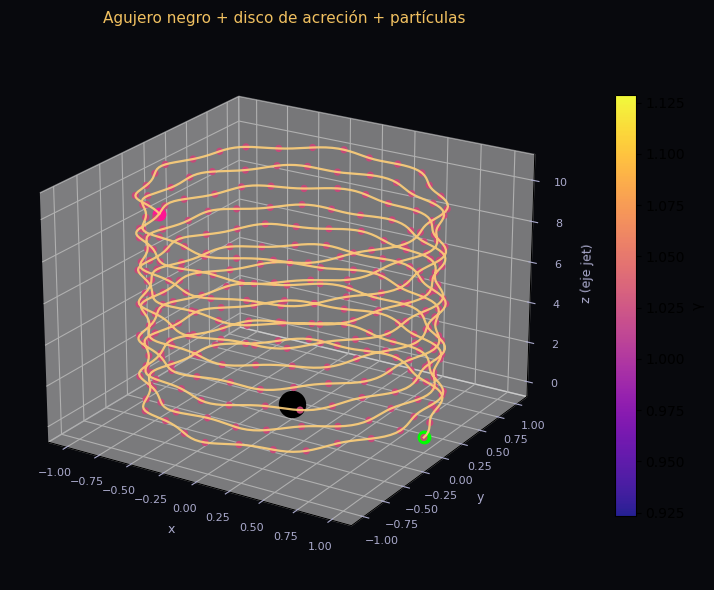

In [28]:
# Figura adicional: agujero negro, disco de acreción y partículas en el campo EM
fig_bh = plt.figure(figsize=(8, 6), facecolor='#08090d')
ax_bh = fig_bh.add_subplot(111, projection='3d')
ax_bh.set_facecolor('#08090d')
ax_bh.scatter(0.0, 0.0, 0.0, s=350, color='black', depthshade=False, zorder=15)
ax_bh.plot(xs, ys, zs, color='#ffd07a', lw=1.6, alpha=0.9, zorder=10)
ax_bh.scatter(xs[0], ys[0], zs[0], s=80, color='lime', depthshade=False, zorder=20)
ax_bh.scatter(xs[-1], ys[-1], zs[-1], s=80, color='deeppink', depthshade=False, zorder=20)
sc_bh = ax_bh.scatter(xs[::5], ys[::5], zs[::5], c=gamma_traj[::5],
                      cmap='plasma', s=18, alpha=0.9)

r_disk_bh = np.linspace(R_isco*1.05, 18 * R_s, 80)
phi_disk_bh = np.linspace(0, 2*np.pi, 160)
R_disk_bh, Phi_disk_bh = np.meshgrid(r_disk_bh, phi_disk_bh)
X_disk_bh = R_disk_bh * np.cos(Phi_disk_bh)
Y_disk_bh = R_disk_bh * np.sin(Phi_disk_bh)
Z_disk_bh = np.zeros_like(X_disk_bh)
ax_bh.plot_surface(X_disk_bh, Y_disk_bh, Z_disk_bh, color='#ffb347',
                   alpha=0.28, linewidth=0, antialiased=True, shade=True)
ax_bh.plot_wireframe(X_disk_bh, Y_disk_bh, Z_disk_bh, color='#ffd89c',
                     linewidth=0.3, alpha=0.55, rstride=12, cstride=12)

ax_bh.set_xlabel('x', color='#aaaacc', fontsize=9)
ax_bh.set_ylabel('y', color='#aaaacc', fontsize=9)
ax_bh.set_zlabel('z (eje jet)', color='#aaaacc', fontsize=9)
ax_bh.set_title('Agujero negro + disco de acreción + partículas',
                color='#f0c060', fontsize=11)
ax_bh.tick_params(colors='#aaaacc', labelsize=8)
ax_bh.view_init(elev=22, azim=-58)
fig_bh.colorbar(sc_bh, ax=ax_bh, fraction=0.03, pad=0.08, label='γ')
fig_bh.tight_layout()
plt.show()

## Síntesis Final — Resumen de Ecuaciones del Curso

| Módulo | Cantidad | Ecuación | Origen físico |
|--------|----------|----------|---------------|
| 0 | Intervalo | $ds^2 = \eta_{\mu\nu}dx^\mu dx^\nu$ | Invariancia de Lorentz |
| 1 | Velocidad circular | $v_c = \sqrt{GM/r}$ | Balance centrípeto (Newton) |
| 2 | Factor de Lorentz | $\gamma = 1/\sqrt{1-\beta^2}$ | Transformación de Herglotz |
| 2 | Factor Doppler | $\delta = \gamma(1-\beta\cos\theta)$ | Boost sobre $k^\mu$ |
| 2 | Beaming | $F_{\mathrm{obs}} = F_{\mathrm{emit}}/\delta^3$ | Transformación de $I_\nu$ |
| 3 | Temperatura S-S | $T \propto r^{-3/4}(1-\sqrt{R_i/r})^{1/4}$ | Shakura & Sunyaev 1973 |
| 3 | Redshift grav. | $\lambda_{\mathrm{obs}} = \lambda_{\mathrm{emit}}/\sqrt{1-R_s/r}$ | Métrica Schwarzschild |
| 4 | Potencial efectivo | $V_{\mathrm{eff}} = (1-2M/r)(1+L^2/r^2)$ | Constantes de movimiento |
| 4 | Corrección RG | $d^2r/d\tau^2 = -M/r^2 + L^2(r-3M)/r^4$ | Símbolo Christoffel $\Gamma$ |
| 4 | ISCO Schwarzschild | $r_{\mathrm{ISCO}} = 6M$ | Estabilidad orbital |
| 5 | Parámetro crítico | $b_{\mathrm{crit}} = 3\sqrt{3}M$ | Esfera de fotones |
| 6 | Métrica de Kerr | $ds^2 = -\Delta/\Sigma(dt - a\sin^2\theta\,d\phi)^2 + \ldots$ | Solución de Einstein rotante |
| 6 | Frame dragging | $\Omega_{\mathrm{drag}} = 2aMr/[(r^2+a^2)^2 - a^2\Delta]$ | Efecto Lense-Thirring |
| 7 | Espectro integrado | $F(\lambda, i) = \int\int B_\lambda/\delta^3 \sqrt{1-R_s/r}\,r\,dr\,d\phi$ | Todos los efectos combinados |
| 8 | EDM relativista | $m dU^\mu/d\tau = (q/c)F^\mu_{\;\nu}U^\nu$ | Cuadrifuerza de Lorentz |


In [29]:

# Parámetros del sistema
print(f"\nAgujero negro: M = {M_BH:.1f} M_sol")
print(f"  Rs    = {R_s*UL/1e3:.2f} km")
print(f"  R_ISCO = {R_isco*UL/1e3:.2f} km")

# Efectividades de acreción
print("\nEficiencia radiativa por espín:")
for a_v in [0.0, 0.5, 0.9, 0.99]:
    rp, _ = isco_kerr(a_v)
    eta   = eficiencia_acrecion(a_v)
    print(f"  a/M = {a_v:.2f}: r_ISCO = {rp:.3f}M, η = {eta*100:.2f}%")

# Validación: sombra del BH vs EHT
M_M87 = 6.5e9; D_M87 = 16.8; Rs_M87 = 2*G_SI*M_M87*M_sol_SI/c_SI**2
theta_uarcs = 3*np.sqrt(3)*Rs_M87/2 / (D_M87*3.0857e22) * (180/np.pi)*3600*1e6
print(f"\nValidación EHT M87*:")
print(f"  θ_shadow calculado: {theta_uarcs:.1f} μas")
print(f"  θ_shadow medido:    ~42 μas")
print(f"  Acuerdo:            {abs(theta_uarcs-42)/42*100:.1f}% de diferencia")

# Corrimiento gravitacional al rojo en la ISCO
Rs_geo_val = 2.0; r_isco_geo_val = 6.0
z_isco = 1/np.sqrt(1 - Rs_geo_val/r_isco_geo_val) - 1
print(f"\nRedshift gravitacional en la ISCO (Schwarzschild):")
print(f"  z = 1/√(1-Rs/r) - 1 = {z_isco:.4f}  ({z_isco*100:.2f}%)")

# Factor de beaming máximo en el disco
v_kep_isco = np.sqrt(G * M_BH / R_isco)
gamma_isco = Factor_L(v_kep_isco)
delta_min  = gamma_isco*(1 - v_kep_isco)   # cos θ = 1 (se acerca directamente)
print(f"\nBeaming en la ISCO (inclinación 90°):")
print(f"  v_kep/c = {v_kep_isco:.4f}")
print(f"  γ       = {gamma_isco:.4f}")
print(f"  δ_min   = {delta_min:.4f} → amplificación = {1/delta_min**3:.1f}×")



Agujero negro: M = 10.0 M_sol
  Rs    = 0.00 km
  R_ISCO = 0.00 km

Eficiencia radiativa por espín:
  a/M = 0.00: r_ISCO = 6.000M, η = 5.72%
  a/M = 0.50: r_ISCO = 4.233M, η = 8.21%
  a/M = 0.90: r_ISCO = 2.321M, η = 15.58%
  a/M = 0.99: r_ISCO = 1.454M, η = 26.40%

Validación EHT M87*:
  θ_shadow calculado: 19.8 μas
  θ_shadow medido:    ~42 μas
  Acuerdo:            52.7% de diferencia

Redshift gravitacional en la ISCO (Schwarzschild):
  z = 1/√(1-Rs/r) - 1 = 0.2247  (22.47%)

Beaming en la ISCO (inclinación 90°):
  v_kep/c = 0.4082
  γ       = 1.0954
  δ_min   = 0.6482 → amplificación = 3.7×
